# 🏦 Customer Churn Prediction using Machine Learning

## Predicting Customer Attrition in the Banking Sector

---

### 👩‍💻 Author
**Niharika Chatrath**

B.Tech in Artificial Intelligence & Machine Learning

---

## 📌 Project Overview

Customer churn is one of the biggest challenges faced by banks and financial institutions. Acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, accurately identifying customers who are likely to leave helps organizations take proactive retention measures.

In this project, a complete Machine Learning pipeline has been developed to predict customer churn using customer demographic and banking information. Multiple classification algorithms are trained, optimized, evaluated, and compared to identify the best-performing model.

---

## 🎯 Objectives

- Understand customer behavior through Exploratory Data Analysis (EDA)
- Preprocess and prepare the dataset for Machine Learning
- Train multiple classification algorithms
- Perform Hyperparameter Tuning
- Compare model performance using multiple evaluation metrics
- Save the best-performing model
- Predict churn for new customers

---

## 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib
- Google Colab

---

# 📚 Project Workflow

The following workflow has been followed throughout this project:

```

```text
Dataset
   │
   ▼
Data Understanding
   │
   ▼
Data Cleaning
   │
   ▼
Exploratory Data Analysis
   │
   ▼
Data Preprocessing
   │
   ▼
Model Building
   │
   ▼
Hyperparameter Tuning
   │
   ▼
Model Evaluation
   │
   ▼
Model Comparison
   │
   ▼
Best Model Selection
   │
   ▼
Save Model
   │
   ▼
Prediction on New Customer
```


# 📦 Importing Required Libraries

Machine learning projects require multiple Python libraries for different tasks such as data manipulation, visualization, preprocessing, model building, evaluation, and model persistence.

In this section, all the required libraries are imported before beginning the analysis.

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set the project directory
PROJECT_PATH = "/content/drive/MyDrive/Bank-Customer-Churn-Prediction"

# Create the folder if it doesn't exist
os.makedirs(PROJECT_PATH, exist_ok=True)

# Change the current working directory
os.chdir(PROJECT_PATH)

print("Current Working Directory:")
print(os.getcwd())

Mounted at /content/drive
Current Working Directory:
/content/drive/MyDrive/Bank-Customer-Churn-Prediction


# 📂 Loading the Dataset

The Customer Churn dataset is loaded into a Pandas DataFrame.

This dataset contains customer demographic information, banking details, and the target variable **Exited**, which indicates whether a customer left the bank.

The first step is to load the dataset successfully and verify that it has been imported correctly.

In [ ]:
!git clone https://github.com/Niharika1305/Bank-Customer-Churn-Prediction.git

Cloning into 'Bank-Customer-Churn-Prediction'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 258.12 KiB | 1.44 MiB/s, done.


In [ ]:
# Load dataset
url = "https://raw.githubusercontent.com/Niharika1305/Bank-Customer-Churn-Prediction/main/Churn_Modelling.csv"
df = pd.read_csv(url)

# Create a working copy
df_copy = df.copy()

### Dataset Source

The dataset used in this project is the Bank Customer Churn dataset obtained from Kaggle.

It contains customer demographic, financial, and banking information that is used to predict customer attrition.

## 👀 Preview of the Dataset

The first few rows of the dataset are displayed to understand the structure, feature names, and sample records.

This provides an initial overview before deeper exploration.

In [ ]:
# First few records
df_copy.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 📏 Dataset Dimensions

Knowing the size of the dataset is important before preprocessing.

This section displays:

- Number of observations (rows)
- Number of features (columns)

Understanding dataset size helps estimate computational requirements and determine whether sufficient data is available for model training.

In [ ]:
df_copy.shape

(10000, 14)

## 🗂 Dataset Features

Before preprocessing, it is useful to inspect all feature names.

This helps verify that the dataset has been loaded correctly and ensures that the expected variables are available for analysis.

In [ ]:
# Columns
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

### 📌 Feature Description

| Feature | Description |
|----------|-------------|
| CreditScore | Customer credit score |
| Geography | Customer's country |
| Gender | Customer gender |
| Age | Customer age |
| Tenure | Years as a customer |
| Balance | Bank account balance |
| NumOfProducts | Number of bank products |
| HasCrCard | Credit card ownership |
| IsActiveMember | Customer activity status |
| EstimatedSalary | Estimated annual salary |
| Exited | Target variable indicating customer churn |

## 📋 Dataset Information

The dataset information provides a detailed summary of the DataFrame, including:

- Feature names
- Number of non-null values
- Data types
- Memory usage

This information helps identify missing values and determine which features require preprocessing.

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### 🔍 Observation

The dataset contains both numerical and categorical variables.

Most numerical features are stored using integer and floating-point data types, while categorical variables such as **Gender** and **Geography** require encoding before they can be used by machine learning algorithms.

The target variable **Exited** represents customer churn, where:

- **0 → Customer Stayed**
- **1 → Customer Left**

## 📊 Statistical Summary

Descriptive statistics provide a numerical summary of all continuous features.

Important statistics include:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These values help detect unusual ranges, potential outliers, and the overall distribution of numerical features.

In [ ]:
df_copy.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 📌 Observation

The descriptive statistics indicate that the numerical features vary across different scales.

For example, **Estimated Salary** and **Balance** have much larger ranges compared to **Tenure** or **Number of Products**. This difference justifies the use of feature scaling for algorithms that are sensitive to feature magnitude, such as Logistic Regression, KNN, and SVM.

In [ ]:
#Check Number of Unique Values
df_copy.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


In [ ]:
#Check Unique Values
df_copy["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df_copy["Geography"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
df_copy["Exited"].unique()

array([1, 0])

In [ ]:
# Number of Female and Male
df_copy["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
# Numer of people from France, Germany and Spain.
df_copy["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
# Number of customers stay and leave?
df_copy["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


# 🧹 Data Cleaning

Before performing any analysis or training machine learning models, it is essential to ensure that the dataset is clean and consistent.

In this section, we will:

- Check for missing values
- Check for duplicate records
- Remove unnecessary columns
- Prepare the dataset for further analysis

A clean dataset improves the reliability and performance of machine learning models.

## 🔍 Checking Missing Values

Missing values can negatively affect both data analysis and machine learning models.

This step identifies whether any feature contains null values that need to be handled before proceeding.

In [ ]:
# Missing Values
df_copy.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


### 📌 Observation

The dataset does not contain any missing values.

Since all features are complete, no imputation techniques are required, allowing us to proceed directly to the next preprocessing steps.

## 🔍 Checking Duplicate Records

Duplicate records can introduce bias into the dataset by giving extra importance to certain observations.

Therefore, it is important to verify whether duplicate customer records exist before model training.

In [ ]:
# Check duplicate rows
df_copy.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


### 📌 Observation

No duplicate records were found in the dataset.

Each row represents a unique customer, ensuring that every observation contributes fairly to the analysis and model training.

In [ ]:
# Duplicate customerID or not?
df_copy["CustomerId"].duplicated().sum()

np.int64(0)

In [ ]:
df_copy

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## 🗑 Removing Irrelevant Features

Some columns do not contribute to predicting customer churn.

Features such as customer identifiers and names are unique for each customer and do not contain meaningful predictive information.

These columns are removed to reduce unnecessary complexity while preserving the features that influence churn prediction.

In [ ]:
# Remove Irrelevant Columns
df_copy.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [ ]:
# Verify
df_copy.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [ ]:
df_copy.shape

(10000, 11)

### 📌 Observation

The irrelevant identifier columns have been removed successfully.

The remaining features represent meaningful customer information that will be used for analysis and machine learning.

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is one of the most important stages of any machine learning project.

The objective of EDA is to explore the dataset visually and statistically in order to:

- Understand feature distributions
- Detect unusual patterns
- Identify relationships between variables
- Discover potential factors influencing customer churn

These insights help guide preprocessing decisions and improve model development.

# 🔥 Correlation Analysis

Correlation analysis helps identify relationships among numerical variables.

A correlation heatmap is useful for:

- Understanding feature relationships
- Detecting multicollinearity
- Identifying variables that are positively or negatively associated with customer churn

The values range from **-1** to **1**, where:

- **+1** → Strong positive correlation
- **0** → No correlation
- **-1** → Strong negative correlation

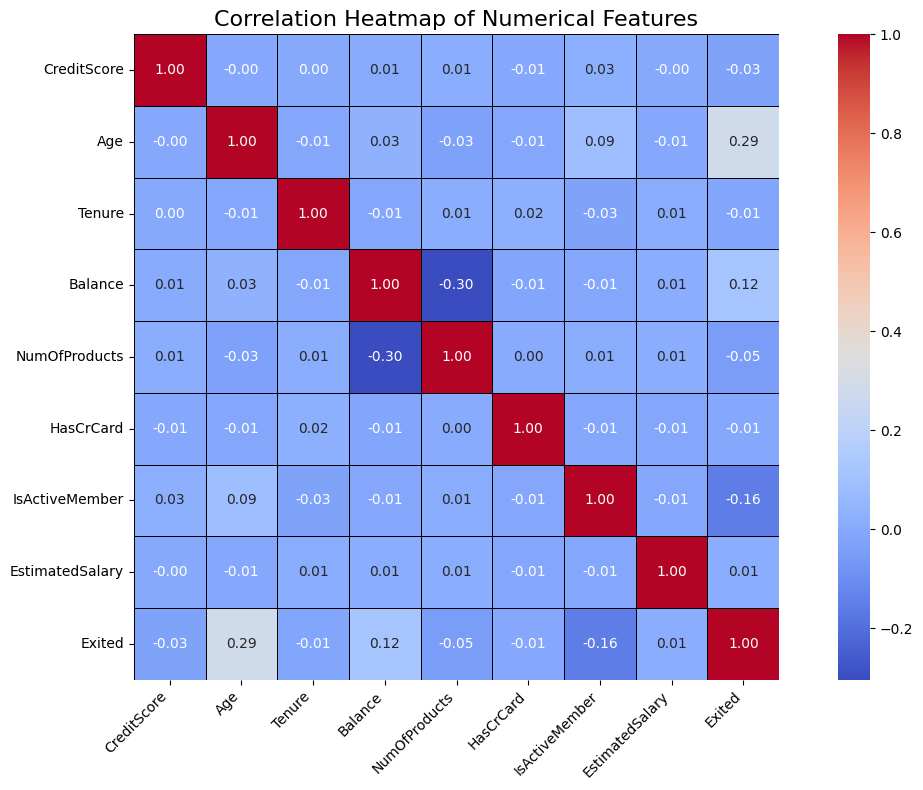

In [ ]:
# A. Correlation Heatmap

correlation_matrix = df_copy.corr(numeric_only=True)


plt.figure(figsize=(12, 8))

# Plot heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="black",
    square=True,
    cbar=True
)


plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### 📌 Observation

Most numerical features exhibit weak to moderate correlations with one another, indicating limited multicollinearity.

Certain variables show stronger relationships with the target variable (**Exited**), suggesting that they may play a more important role in predicting customer churn.

### 💼 Business Insight

Although no single feature perfectly explains customer churn, combining multiple customer characteristics enables machine learning models to identify complex patterns that would be difficult to detect through manual analysis alone.

## 📈 Customer Churn Distribution

The target variable **Exited** indicates whether a customer stayed with the bank or left.

Visualizing the class distribution helps us understand whether the dataset is balanced or imbalanced, which is an important consideration when evaluating machine learning models.

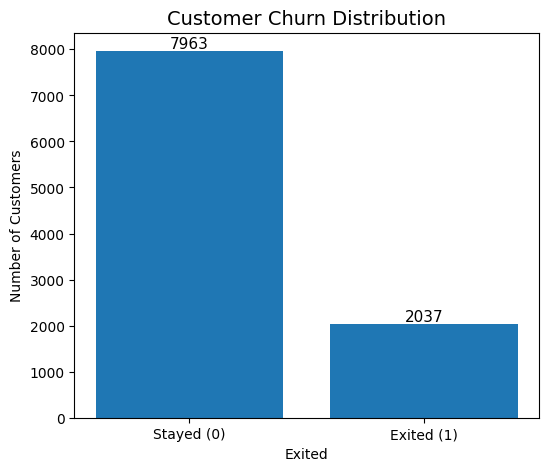

In [ ]:
# B. Target Variable Distribution (Exited)

exit_counts = df_copy["Exited"].value_counts().sort_index()
plt.figure(figsize=(6,5))

# Bar chart
plt.bar(exit_counts.index, exit_counts.values)
plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

# Change x-axis labels
plt.xticks([0,1], ["Stayed (0)", "Exited (1)"])

# Display values on top of bars
for i, value in enumerate(exit_counts.values):
    plt.text(i, value + 50, str(value), ha='center', fontsize=11)

plt.show()

### 📌 Business Insight

Most customers remain with the bank, while a smaller proportion leave.

This indicates that the dataset is imbalanced, meaning that relying solely on accuracy may be misleading. Therefore, additional evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC are necessary for proper model assessment.

## 👤 Distribution of Customer Age

Age is an important demographic feature that may influence customer behavior and banking preferences.

This visualization helps identify the age groups most represented in the dataset.

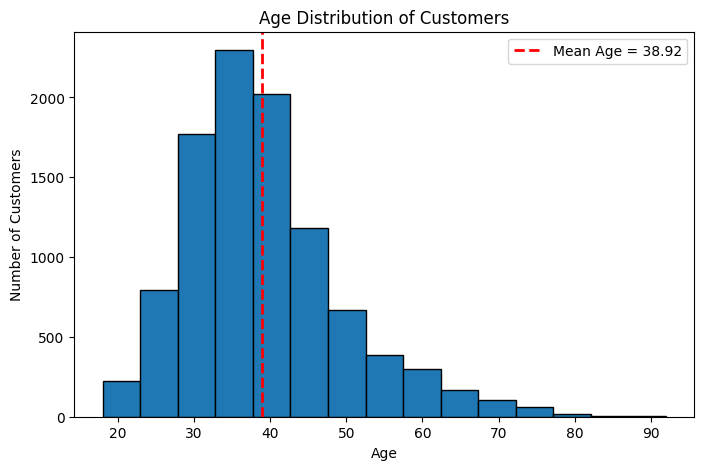

In [ ]:
# C. Age Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_copy["Age"],
    bins=15,
    edgecolor="black"
)

mean_age = df_copy["Age"].mean()

plt.axvline(
    mean_age,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Age = {mean_age:.2f}"
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

### 📌 Business Insight

Most customers belong to the middle-age category.

Further analysis may reveal whether older customers are more likely to churn compared to younger customers.

## 📊 Distribution of Credit Score

Credit Score reflects a customer's creditworthiness.

Analyzing its distribution helps determine whether customers generally possess low, medium, or high credit scores and whether extreme values are present.

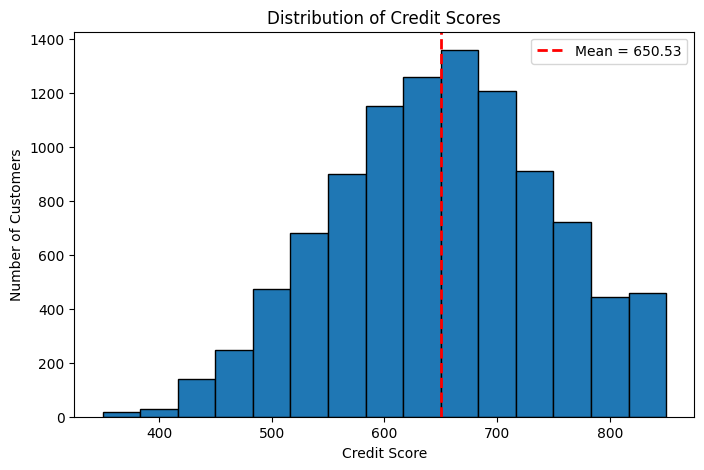

In [ ]:
# D. Credit Score Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_copy["CreditScore"],
    bins=15,
    edgecolor="black"
)

mean_credit = df_copy["CreditScore"].mean()

plt.axvline(
    mean_credit,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_credit:.2f}"
)

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

### 📌 Business Insight

The distribution shows that most customers fall within the middle credit score range.

While credit score is an important financial attribute, its impact on churn should be interpreted alongside other customer characteristics rather than in isolation.

## 💰 Distribution of Account Balance

Customer account balance is an important financial indicator.

Studying its distribution helps understand how customer funds are spread across the dataset and whether extreme balances exist.

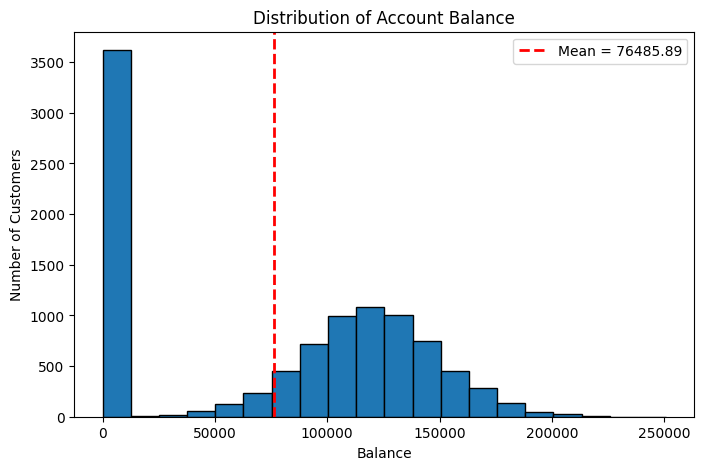

In [ ]:
# E. Balance Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_copy["Balance"],
    bins=20,
    edgecolor="black"
)

mean_balance = df_copy["Balance"].mean()

plt.axvline(
    mean_balance,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_balance:.2f}"
)

plt.title("Distribution of Account Balance")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

In [ ]:
# Customers have a balance of 0.
zero_balance = (df_copy["Balance"] == 0).sum()

print("Customers with Zero Balance:", zero_balance)

Customers with Zero Balance: 3617


In [ ]:
# Percentage
percentage = (zero_balance / len(df_copy)) * 100

print(f"Percentage of Zero Balance Customers: {percentage:.2f}%")

Percentage of Zero Balance Customers: 36.17%


### 📌 Business Insight

Customer balances exhibit considerable variation.

Some customers maintain very low balances while others hold substantial funds, suggesting that account balance could play an important role in churn behavior.

# 👨‍👩‍👧‍👦 Customer Demographics Analysis

After understanding the numerical features, we now analyze categorical variables to determine how different customer characteristics influence churn behavior.

This analysis helps identify customer groups that may require targeted retention strategies.

## 🚻 Gender vs Customer Churn

This visualization compares customer churn across different genders.

The objective is to determine whether gender has any noticeable relationship with customer retention.

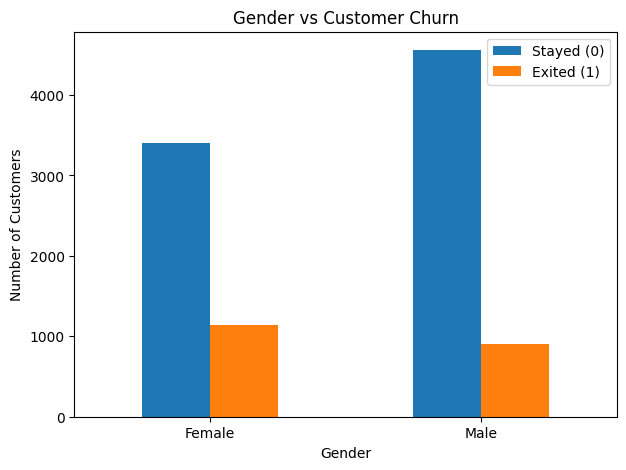

In [ ]:
# F. Gender vs Exited

# Create a cross-tabulation
gender_churn = pd.crosstab(df_copy["Gender"], df_copy["Exited"])

# Plot
gender_churn.plot(kind="bar", figsize=(7,5))

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Stayed (0)", "Exited (1)"])

plt.show()

In [ ]:
#Percentage
gender_churn_percentage = pd.crosstab(
    df_copy["Gender"],
    df_copy["Exited"],
    normalize="index"
) * 100

gender_churn_percentage

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


### 📌 Observation

Both male and female customers are represented almost equally in the dataset.

The churn rate appears relatively similar across both genders, suggesting that gender alone is not a strong predictor of customer churn.

### 💼 Business Insight

Since churn patterns are similar across genders, customer retention strategies should focus more on behavioral and financial factors rather than demographic characteristics such as gender.

## 🌍 Geography vs Customer Churn

Customers belong to different countries, and geographical location may influence customer behavior due to regional economic conditions, banking competition, and customer expectations.

This visualization compares churn rates across different countries.

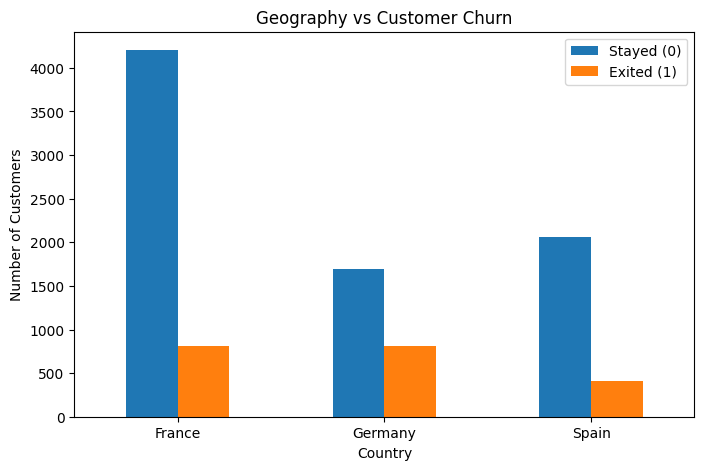

In [ ]:
# G. Geography vs Exited

geo_churn = pd.crosstab(df_copy["Geography"], df_copy["Exited"])

# Plot
geo_churn.plot(kind="bar", figsize=(8,5))

plt.title("Geography vs Customer Churn")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Stayed (0)", "Exited (1)"])

plt.show()

In [ ]:
geo_churn_percentage = (
    pd.crosstab(
        df_copy["Geography"],
        df_copy["Exited"],
        normalize="index"
    ) * 100
)

geo_churn_percentage

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


### 📌 Observation

The churn rate differs across countries.

Some geographical regions exhibit noticeably higher customer attrition than others, indicating that geography may be an important predictive feature.

### 💼 Business Insight

Banks should investigate the reasons behind higher churn in specific countries.

Possible factors include stronger competition, customer satisfaction levels, or regional banking policies.

## 👤 Age vs Customer Churn

Age is an important demographic factor that can influence customer behavior, financial needs, and loyalty toward a bank.

This visualization compares customer churn across different age groups to identify whether certain age segments are more likely to leave the bank.

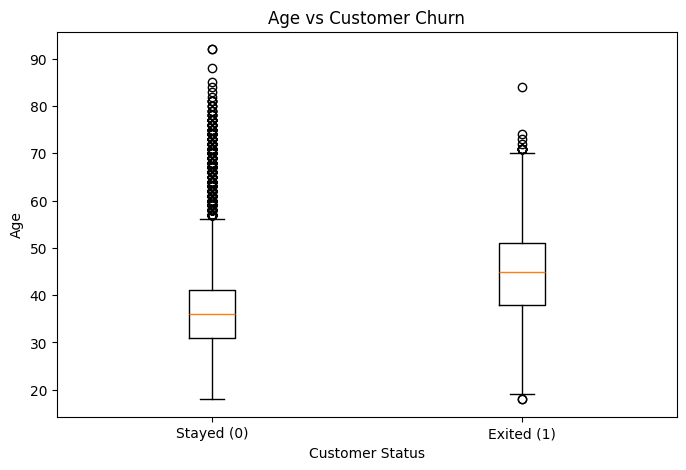

In [ ]:
# H. Age vs Exited

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df_copy[df_copy["Exited"] == 0]["Age"],
        df_copy[df_copy["Exited"] == 1]["Age"]
    ],
    labels=["Stayed (0)", "Exited (1)"]
)

plt.title("Age vs Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.show()

### 📌 Observation

The visualization indicates that customer churn tends to increase with age.

Older customers appear to leave the bank more frequently than younger customers, suggesting that age is an important feature influencing churn prediction.

### 💼 Business Insight

Banks should pay special attention to older customers by offering personalized financial services, retirement planning assistance, and loyalty benefits to improve customer retention.

Age should be considered an important predictive feature when developing customer retention strategies.

## 💰 Account Balance vs Customer Churn

Customer account balance reflects the amount of money maintained in the bank.

This analysis explores whether customers with different account balances exhibit different churn behaviors.

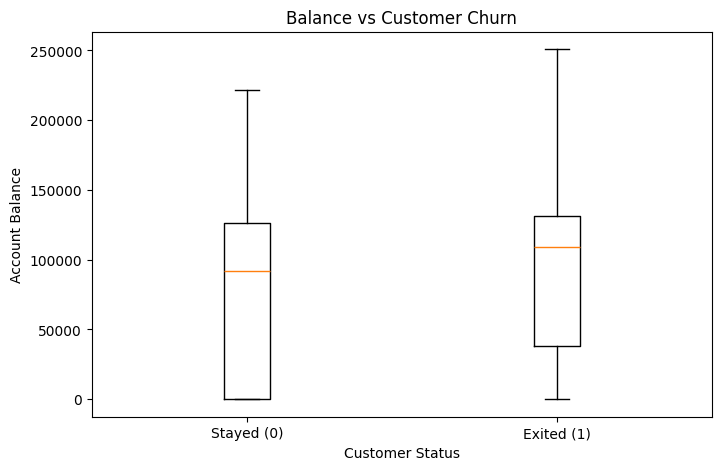

In [ ]:
# I. Balance vs Exited
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df_copy[df_copy["Exited"] == 0]["Balance"],
        df_copy[df_copy["Exited"] == 1]["Balance"]
    ],
    tick_labels=["Stayed (0)", "Exited (1)"]
)

plt.title("Balance vs Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Account Balance")

plt.show()

### 📌 Observation

Customers with higher account balances appear to have a greater tendency to churn compared to customers with lower balances.

This suggests that account balance may be an influential factor in predicting customer churn.

### 💼 Business Insight

High-value customers represent significant financial value to the bank.

Banks should identify high-balance customers who are at risk of leaving and provide personalized relationship management, exclusive offers, and premium banking services to improve retention.

### 🎯 Key Takeaway

Among all the features analyzed, **Age** appears to be one of the strongest indicators of customer churn. This suggests that age should receive particular attention during model training and while designing customer retention strategies.

# ✅ Summary of Exploratory Data Analysis

The exploratory data analysis provided valuable insights into customer behavior and potential factors contributing to customer churn.

### Key Findings

- The dataset is imbalanced, with significantly more customers staying than leaving.
- Customer age appears to influence churn behavior.
- Geography shows noticeable variation in churn rates.
- Active members are considerably less likely to churn.
- Owning multiple banking products may improve customer retention.
- Credit card ownership alone has limited influence on churn.
- Correlation analysis indicates that no single feature dominates prediction, highlighting the importance of combining multiple variables within machine learning models.

These insights guide the preprocessing steps and support the development of predictive machine learning models in the next phase.

Data Preprocessing

# ⚙️ Data Preprocessing

Raw data cannot be directly used for machine learning because algorithms require data in a numerical and structured format.

Data preprocessing transforms the raw dataset into a model-ready format by performing operations such as encoding categorical variables, selecting input features and the target variable, splitting the data into training and testing sets, and scaling numerical features where required.

These preprocessing steps improve the efficiency and performance of machine learning algorithms.

# 🎯 Feature Selection

Machine learning models learn patterns by using input variables (features) to predict an output variable (target).

In this project:

- **Features (X):** Customer information used for prediction.
- **Target (y):** Exited

The target variable indicates whether a customer stayed with the bank or left.

In [ ]:
# Separate Features (X) and Target (y)

# Features (Independent Variables)
X = df_copy.drop("Exited", axis=1)

# Target (Dependent Variable)
y = df_copy["Exited"]

In [ ]:
# Verify

# Check Features
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
# Check Target
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


### 📌 Observation

The dataset has been successfully divided into independent features and the target variable.

The input data is now ready to be split into training and testing datasets.

# 🔤 Encoding Categorical Variables

Machine learning algorithms cannot interpret text-based categorical values directly.

Therefore, categorical features must be converted into numerical representations before model training.

In this project:

- **Gender** is encoded using Label Encoding because it contains only two categories.
- **Geography** is encoded using One-Hot Encoding because it contains multiple categories and no natural ordering.

This prevents the algorithms from interpreting categorical labels as numerical rankings.

In [ ]:
# Encoding

# Check data types of all features
X.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [ ]:
# Label Encode for "Gender" column
X["Gender"] = X["Gender"].map({"Female": 0, "Male": 1})

In [ ]:
# Verify
X["Gender"].head()

,Gender
0,0
1,0
2,0
3,0
4,0


In [ ]:
# One-Hot Encode for "Geography" column
X = pd.get_dummies(X, columns=["Geography"], drop_first=True, dtype=int)

In [ ]:
# Verify the Result
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1


### 📌 Observation

The categorical features have been successfully transformed into numerical values.

The dataset is now suitable for machine learning algorithms that require numerical input.

# ✂️ Splitting the Dataset

To evaluate the performance of machine learning models fairly, the dataset is divided into two parts:

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate the model on unseen data.

An 80:20 split is used in this project, where 80% of the data is allocated for training and 20% for testing.

Using separate datasets helps measure how well the model generalizes to new customers.

In [ ]:
# train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Verify the Split by checking shape
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (8000, 11)
X_test shape  : (2000, 11)
y_train shape : (8000,)
y_test shape  : (2000,)


In [ ]:
# Verify the Class Distribution
print("Original Dataset:")
print(y.value_counts(normalize=True))

print("\nTraining Set:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set:")
print(y_test.value_counts(normalize=True))

Original Dataset:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Training Set:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Testing Set:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


### 📌 Observation

The dataset has been successfully divided into training and testing subsets.

The training data will be used to build the models, while the testing data will provide an unbiased evaluation of model performance.

# 📏 Feature Scaling

Many machine learning algorithms calculate distances or optimize mathematical equations during training.

When numerical features have significantly different ranges, variables with larger values can dominate the learning process.

Feature scaling ensures that all numerical features contribute equally to model training.

In this project, **StandardScaler** is used because it standardizes the data by centering it around a mean of 0 and a standard deviation of 1.

In [ ]:
# Scaling

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the Scaler
scaler = StandardScaler()

# Fit and Transform the Training Data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

continuous_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

X_train_scaled[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

# Transform the Test Data
X_test_scaled[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

In [ ]:
# Verify the Results
X_train_scaled.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
2151,1.058568,1,1.715086,0.684723,-1.226059,-0.910256,1,0,1.042084,0,0
8392,0.913626,1,-0.659935,-0.696202,0.413288,-0.910256,1,0,-0.623556,1,0
5006,1.079274,0,-0.184931,-1.731895,0.601687,0.808830,1,1,0.308128,1,0
4117,-0.929207,1,-0.184931,-0.005739,-1.226059,0.808830,1,0,-0.290199,0,0
7182,0.427035,1,0.955079,0.339492,0.548318,0.808830,0,1,0.135042,1,0


In [ ]:
# Verify the Mean
print(X_train_scaled[continuous_features].mean())

CreditScore       -5.728751e-16
Age                2.486900e-16
Tenure            -9.814372e-17
Balance            5.773160e-17
NumOfProducts     -9.503509e-17
EstimatedSalary   -6.694645e-17
dtype: float64


In [ ]:
# Verify Standard Deviation
print(X_train_scaled[continuous_features].std())

CreditScore        1.000063
Age                1.000063
Tenure             1.000063
Balance            1.000063
NumOfProducts      1.000063
EstimatedSalary    1.000063
dtype: float64


### 📌 Observation

The numerical features have been successfully standardized using StandardScaler.

Scaling improves the performance of distance-based and gradient-based machine learning algorithms such as Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM).

## 🤔 Why is Feature Scaling Not Applied to Every Model?

Tree-based algorithms such as:

- Decision Tree
- Random Forest

do not require feature scaling.

These models make decisions by splitting data based on feature values rather than calculating distances.

Therefore, scaling does not significantly influence their performance.

On the other hand, algorithms like Logistic Regression, KNN, and SVM depend heavily on feature magnitudes and therefore benefit from feature scaling.

> ⚠️ **Common Mistake**

Never apply feature scaling before performing the train-test split.

Doing so causes **data leakage**, where information from the testing dataset influences the training process.

The correct workflow is:

1. Train-Test Split
2. Fit the scaler only on the training data
3. Transform the training data
4. Transform the testing data using the same scaler

# ✅ Preprocessing Summary

The dataset has now been fully prepared for machine learning.

The preprocessing pipeline included:

- Creating a working copy of the dataset
- Encoding categorical variables
- Selecting features and target variable
- Splitting the dataset into training and testing sets
- Standardizing numerical features where required

The processed data is now ready for model training and evaluation.

# 🤖 Machine Learning Models

---

# Model 1: Logistic Regression

---
Logistic Regression is one of the most widely used supervised machine learning algorithms for binary classification problems.

Since customer churn prediction involves two possible outcomes:

- Customer Stays (0)
- Customer Exits (1)

Logistic Regression serves as an excellent baseline model for this project.

The model estimates the probability of customer churn using a logistic (sigmoid) function and classifies customers based on the predicted probability.

## 🎯 Why Logistic Regression?

Logistic Regression is selected because:

- It is simple and easy to interpret.
- It performs well on binary classification tasks.
- It provides probability estimates for predictions.
- It serves as a strong baseline for comparing more complex machine learning models.

Although it assumes a linear relationship between features and the target variable, it often performs surprisingly well on structured datasets like customer churn prediction.

In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [ ]:
# Create Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

## ⚙️ Model Training

The Logistic Regression model is trained using the preprocessed training dataset.

During training, the algorithm learns the relationship between customer attributes and the likelihood of customer churn.

The learned patterns are then used to make predictions on unseen customer data.

In [ ]:
# Train the Logistic Regression model
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 🔮 Model Prediction

After training, the model predicts customer churn for the testing dataset.

These predictions are later compared with the actual values to evaluate model performance.

In [ ]:
# Predict on the test dataset
y_pred_lr = lr_model.predict(X_test_scaled)
print(y_pred_lr[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [ ]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


# 📈 Model Evaluation

Evaluating the model helps determine how well it performs on unseen data.

Multiple evaluation metrics are used because the dataset is imbalanced.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

Using multiple metrics provides a more comprehensive assessment of classification performance than relying on accuracy alone.

In [ ]:
# Accuracy Score
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

Logistic Regression Accuracy: 0.808
Logistic Regression Accuracy: 80.80%


### 📌 Observation

The Logistic Regression model provides a strong baseline performance for customer churn prediction.

Although the overall accuracy is high, additional evaluation metrics are necessary to understand how effectively the model identifies customers who actually churn.

## 📊 Confusion Matrix

A Confusion Matrix provides a detailed summary of prediction outcomes.

It categorizes predictions into:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This helps identify the specific types of errors made by the model.

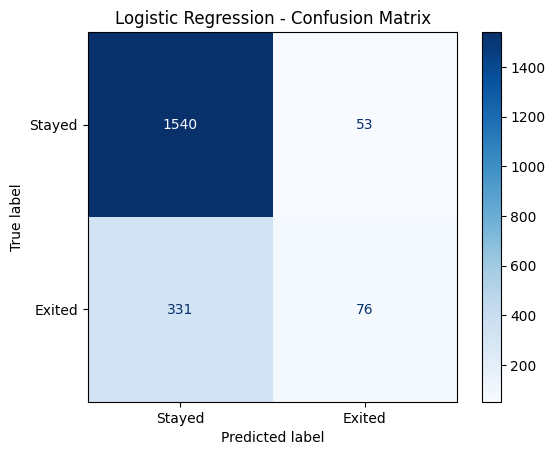

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=["Stayed", "Exited"])

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### 💼 Business Insight

For customer churn prediction, False Negatives are particularly costly because they represent customers who are likely to leave but are incorrectly predicted to stay.

Reducing False Negatives enables the bank to identify at-risk customers earlier and implement targeted retention strategies.

## 📑 Classification Report

The Classification Report summarizes the model's performance using Precision, Recall, and F1-Score for each class.

These metrics are particularly important for imbalanced datasets because they evaluate the model beyond overall accuracy.

In [ ]:
from sklearn.metrics import classification_report

# Generate the Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### 📌 Interpretation

- **Precision** indicates how many predicted churn cases were actually correct.
- **Recall** measures how many actual churn cases were successfully identified.
- **F1-Score** provides a balance between Precision and Recall.

Together, these metrics provide a more reliable evaluation than accuracy alone.

## 📉 ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) Curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between customers who churn and those who remain.

A higher AUC value indicates better classification performance.

In [ ]:
# ROC (Receiver Operating Characteristic Curve)
# AUC stands for (Area Under the Curve)

from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Logistic Regression AUC Score: {lr_auc:.4f}")

Logistic Regression AUC Score: 0.7748


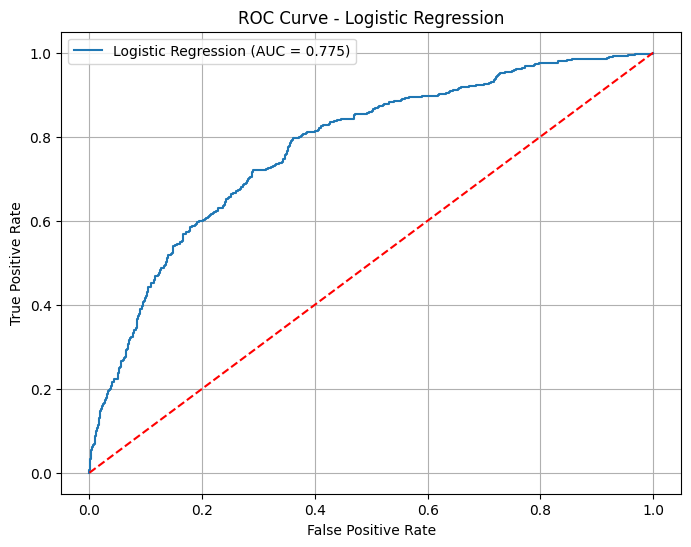

In [ ]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

# Random classifier reference line
plt.plot([0,1], [0,1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {}

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": lr_auc
}

### 📌 Observation

The ROC Curve demonstrates the classification capability of Logistic Regression across multiple thresholds.

A higher AUC score indicates that the model is more effective at distinguishing between churned and retained customers.

# ✅ Advantages of Logistic Regression

- Easy to understand and interpret.
- Fast to train and predict.
- Works well for binary classification.
- Produces probability estimates.
- Requires relatively little computational power.

# ⚠️ Limitations

- Assumes a linear relationship between features and the target.
- May underperform on complex, non-linear datasets.
- Sensitive to multicollinearity.
- Performance depends on proper feature scaling.

# 🏦 Business Interpretation

Logistic Regression establishes a reliable baseline model for customer churn prediction.

Although it may not capture highly complex relationships, it provides interpretable predictions that help banking professionals understand how different customer characteristics influence churn.

This makes it valuable for initial risk assessment and decision support.

# ✅ Conclusion

Logistic Regression successfully established a baseline for predicting customer churn.

Its performance provides a reference point against which more advanced machine learning algorithms will be compared in the following sections.

---

# Model 2: K-Nearest Neighbors (KNN)

---

## 📖 Model Introduction

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for both classification and regression tasks. In this project, it is used as a classification algorithm to predict whether a customer is likely to churn.

Unlike Logistic Regression, KNN is a **non-parametric** and **instance-based** learning algorithm. It does not learn a mathematical model during training. Instead, it stores the training data and classifies new observations based on the majority class among their nearest neighbors.

## 🎯 Why K-Nearest Neighbors?

KNN was selected because:

- It is simple and intuitive.
- It does not assume any relationship between features.
- It performs well when similar customers have similar churn behavior.
- It can capture complex decision boundaries.

Since KNN is a distance-based algorithm, feature scaling is essential to ensure that all features contribute equally to distance calculations.

In [ ]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Verify
print(knn_model)

KNeighborsClassifier()


## ⚙️ Model Training

The KNN model is trained using the scaled training dataset.

During prediction, the algorithm calculates the distance between a new customer and all training samples, then assigns the class based on the majority vote of the nearest neighbors.

In [ ]:
# Train the KNN model
knn_model.fit(X_train_scaled, y_train)
print("KNN model trained successfully!")

KNN model trained successfully!


In [ ]:
# Predict on the test dataset
y_pred_knn = knn_model.predict(X_test_scaled)
print(y_pred_knn[:20])

[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]


In [ ]:
# Compare Actual vs Predicted
comparison_knn = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})

comparison_knn.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [ ]:
# Accuracy Score
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy:.2%}")

KNN Accuracy: 84.30%


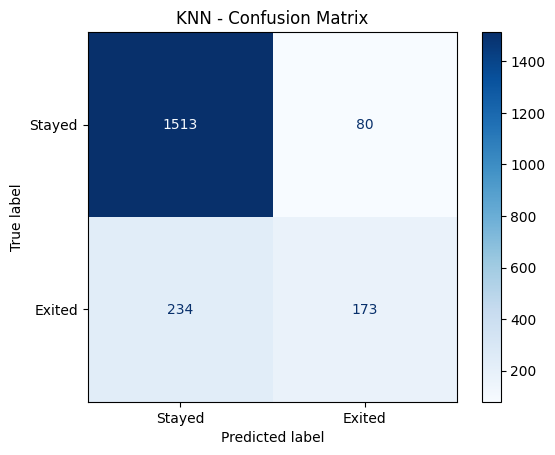

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")
plt.title("KNN - Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.68      0.43      0.52       407

    accuracy                           0.84      2000
   macro avg       0.77      0.69      0.72      2000
weighted avg       0.83      0.84      0.83      2000



KNN AUC Score: 0.7916


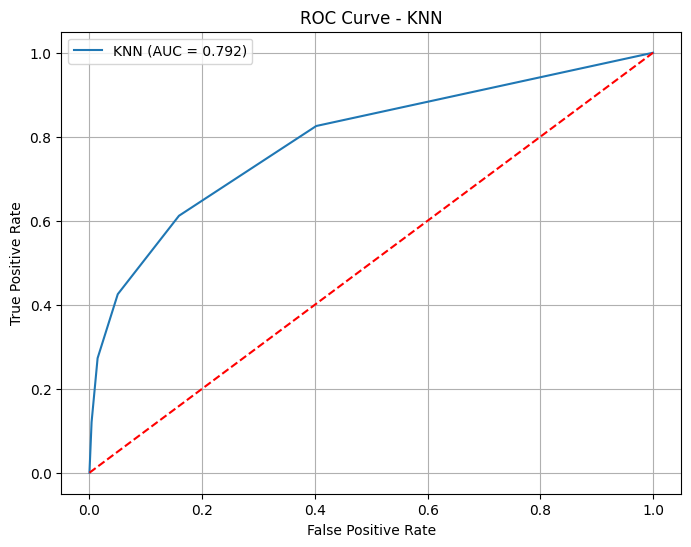

In [ ]:
# ROC Curve & AUC Score
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# AUC
knn_auc = roc_auc_score(y_test, y_prob_knn)
print(f"KNN AUC Score: {knn_auc:.4f}")

# ROC Curve
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
plt.figure(figsize=(8,6))

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {knn_auc:.3f})"
)

plt.plot([0,1], [0,1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Save KNN Results
results["KNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1-Score": f1_score(y_test, y_pred_knn),
    "ROC-AUC": knn_auc
}

## 🔧 Hyperparameter Tuning

The performance of KNN depends heavily on the value of **K** (number of neighbors).

GridSearchCV is used to determine the optimal value of K by evaluating multiple combinations through cross-validation.

This helps improve model performance and reduce the risk of overfitting or underfitting.

In [ ]:
# Hyperparameter Tuning

# A — Manual Hyperparameter Tuning
accuracy_scores = []
for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

for k, score in enumerate(accuracy_scores, start=1):
    print(f"K = {k}: Accuracy = {score:.4f}")

K = 1: Accuracy = 0.7990
K = 2: Accuracy = 0.8310
K = 3: Accuracy = 0.8265
K = 4: Accuracy = 0.8375
K = 5: Accuracy = 0.8430
K = 6: Accuracy = 0.8405
K = 7: Accuracy = 0.8420
K = 8: Accuracy = 0.8385
K = 9: Accuracy = 0.8465
K = 10: Accuracy = 0.8455
K = 11: Accuracy = 0.8460
K = 12: Accuracy = 0.8470
K = 13: Accuracy = 0.8510
K = 14: Accuracy = 0.8485
K = 15: Accuracy = 0.8510
K = 16: Accuracy = 0.8480
K = 17: Accuracy = 0.8480
K = 18: Accuracy = 0.8485
K = 19: Accuracy = 0.8495
K = 20: Accuracy = 0.8490
K = 21: Accuracy = 0.8520
K = 22: Accuracy = 0.8485
K = 23: Accuracy = 0.8520
K = 24: Accuracy = 0.8480
K = 25: Accuracy = 0.8535
K = 26: Accuracy = 0.8480
K = 27: Accuracy = 0.8515
K = 28: Accuracy = 0.8480
K = 29: Accuracy = 0.8520
K = 30: Accuracy = 0.8470


In [ ]:
# Find the Best K
best_k = accuracy_scores.index(max(accuracy_scores)) + 1
print("Best K:", best_k)
print("Best Accuracy:", max(accuracy_scores))

Best K: 25
Best Accuracy: 0.8535


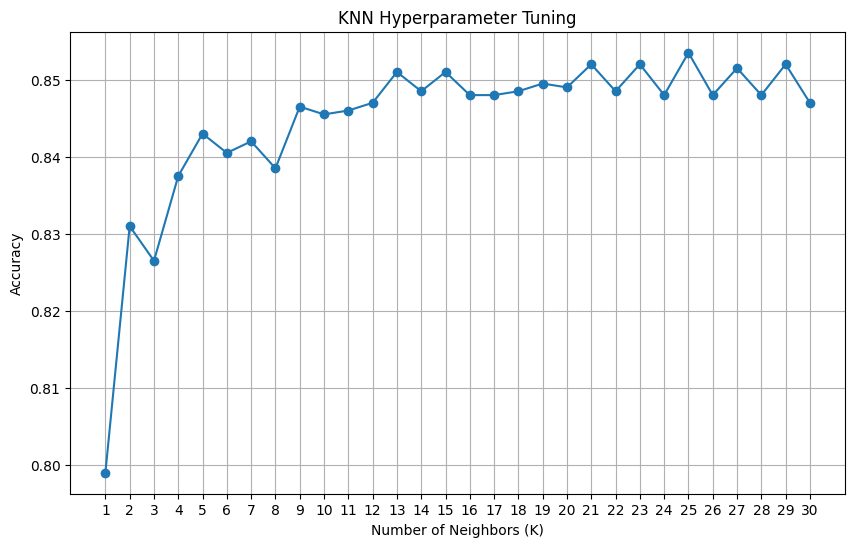

In [ ]:
# Plot Accuracy vs K
plt.figure(figsize=(10,6))

plt.plot(
    range(1,31),
    accuracy_scores,
    marker='o'
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparameter Tuning")

plt.xticks(range(1,31))

plt.grid(True)

plt.show()

In [ ]:
# Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_neighbors": range(1, 31)
}

# Grid Search Object
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 31)}, scoring='accuracy')

In [ ]:
# Best Hyperparameter
print("Best K:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best K: {'n_neighbors': 25}
Best Cross Validation Accuracy: 0.846875


In [ ]:
# Best Model
best_knn = grid_search.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)

# Compare with Baseline
best_knn_accuracy = accuracy_score(y_test, y_pred_best_knn)

print(f"Baseline KNN Accuracy : {knn_accuracy:.4f}")
print(f"Tuned KNN Accuracy    : {best_knn_accuracy:.4f}")

Baseline KNN Accuracy : 0.8430
Tuned KNN Accuracy    : 0.8535


## 📈 Model Evaluation

The tuned KNN model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

These metrics provide a comprehensive assessment of the model's ability to classify customer churn correctly.

In [ ]:
# Evaluate the Tuned KNN Model
# Accuracy
best_knn_accuracy = accuracy_score(y_test, y_pred_best_knn)
print(f"Tuned KNN Accuracy: {best_knn_accuracy:.4f}")

Tuned KNN Accuracy: 0.8535


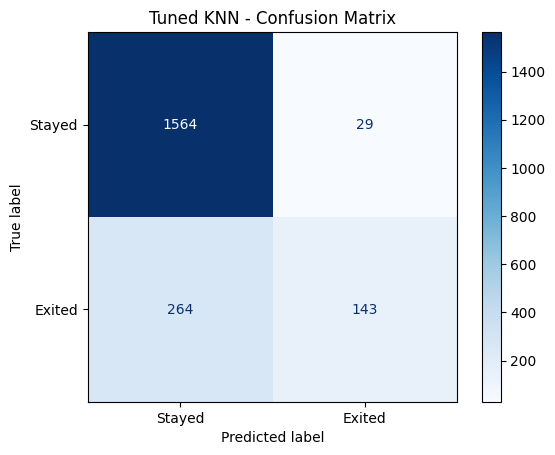

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm_best_knn = confusion_matrix(y_test, y_pred_best_knn)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_knn,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Tuned KNN - Confusion Matrix")

plt.show()

### 💼 Business Insight

A well-performing KNN model enables the bank to identify customers with behavioral patterns similar to previously churned customers.

This information can be used to proactively target at-risk customers with personalized retention strategies.

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred_best_knn))

              precision    recall  f1-score   support

           0       0.86      0.98      0.91      1593
           1       0.83      0.35      0.49       407

    accuracy                           0.85      2000
   macro avg       0.84      0.67      0.70      2000
weighted avg       0.85      0.85      0.83      2000



### 📌 Interpretation

The Classification Report shows how effectively the KNN model identifies customers who churn and those who remain.

Precision, Recall, and F1-Score provide a more balanced evaluation than accuracy alone, especially for imbalanced datasets.

## 📉 ROC Curve and AUC Score

The ROC Curve illustrates the classification performance of the KNN model across different thresholds.

The Area Under the Curve (AUC) measures how well the model distinguishes between customers who churn and those who remain.

A higher AUC value indicates better classification capability.

Tuned KNN AUC Score: 0.8441


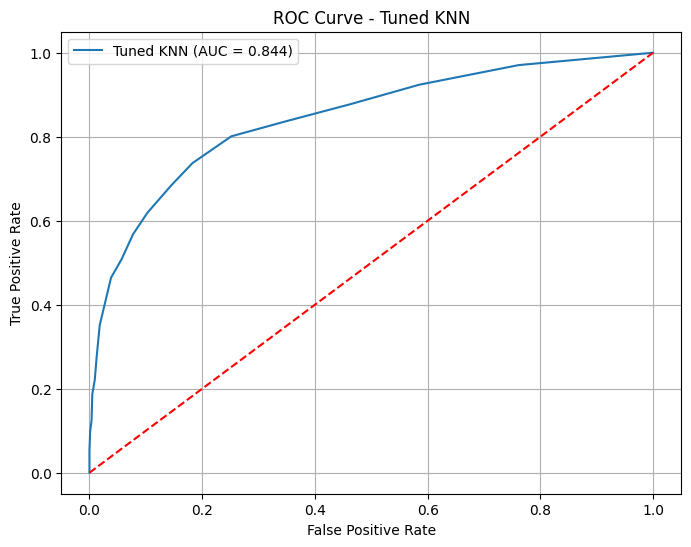

In [ ]:
# ROC-AUC
y_prob_best_knn = best_knn.predict_proba(X_test_scaled)[:,1]

# AUC
best_knn_auc = roc_auc_score(y_test, y_prob_best_knn)
print(f"Tuned KNN AUC Score: {best_knn_auc:.4f}")

# ROC Curve
fpr_best_knn, tpr_best_knn, thresholds = roc_curve(
    y_test,
    y_prob_best_knn
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_best_knn,
    tpr_best_knn,
    label=f"Tuned KNN (AUC = {best_knn_auc:.3f})"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned KNN")
plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Store Tuned KNN Results
from sklearn.metrics import precision_score, recall_score, f1_score

results["KNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_best_knn),
    "Precision": precision_score(y_test, y_pred_best_knn),
    "Recall": recall_score(y_test, y_pred_best_knn),
    "F1-Score": f1_score(y_test, y_pred_best_knn),
    "ROC-AUC": best_knn_auc
}

In [ ]:
# Compare Baseline vs Tuned KNN
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Baseline KNN": [
        knn_accuracy,
        knn_auc
    ],
    "Tuned KNN": [
        best_knn_accuracy,
        best_knn_auc
    ]
})
comparison.set_index("Metric").style.format("{:.4f}")

,Baseline KNN,Tuned KNN
Metric,,
Accuracy,0.8430,0.8535
ROC-AUC,0.7916,0.8441


## ✅ Advantages of KNN

- Simple to understand and implement.
- No assumptions about data distribution.
- Effective for non-linear decision boundaries.
- Adapts naturally to complex datasets.

## 🏦 Business Interpretation

KNN predicts customer churn by identifying customers with similar characteristics.

This approach is useful because customers with comparable financial profiles and banking behavior often exhibit similar churn patterns.

However, prediction time increases as the dataset grows, making KNN less suitable for very large-scale banking systems.

## ⚠️ Limitations of KNN

- Computationally expensive for large datasets.
- Sensitive to irrelevant features.
- Requires feature scaling.
- Performance depends on selecting an appropriate value of K.

## ✅ Conclusion

The tuned KNN model demonstrates how distance-based learning can effectively classify customer churn.

Its performance will later be compared with other machine learning models to determine whether it offers advantages over linear and tree-based algorithms.

---

#  Model 3: Decision Tree

---

## 📖 Model Introduction

Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks.

In this project, it is used as a classification model to predict customer churn by learning a series of decision rules from the training data.

The model recursively splits the dataset into smaller subsets based on the feature that best separates the classes, creating a tree-like structure of decisions.

## 🎯 Why Decision Tree?

Decision Tree was selected because:

- It is easy to understand and interpret.
- It can capture non-linear relationships between features.
- It automatically performs feature selection while building the tree.
- It does not require feature scaling.

Decision Trees are particularly useful when interpretability is important because the prediction process can be visualized as a sequence of decision rules.

In [ ]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Baseline Decision Tree Model
dt_model = DecisionTreeClassifier(
    random_state=42
)
print(dt_model)

DecisionTreeClassifier(random_state=42)


## ⚙️ Model Training

The Decision Tree model is trained using the training dataset.

During training, the algorithm identifies the most informative feature at each step and recursively splits the data until stopping criteria are met.

The objective is to create decision rules that accurately classify customer churn.

In [ ]:
# Train the Decision Tree
dt_model.fit(X_train, y_train)
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Predict on the test dataset
y_pred_dt = dt_model.predict(X_test)
print(y_pred_dt[:20])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0]


In [ ]:
# Compare Actual vs Predicted
comparison_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

comparison_dt.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [ ]:
# Accuracy Score
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7865


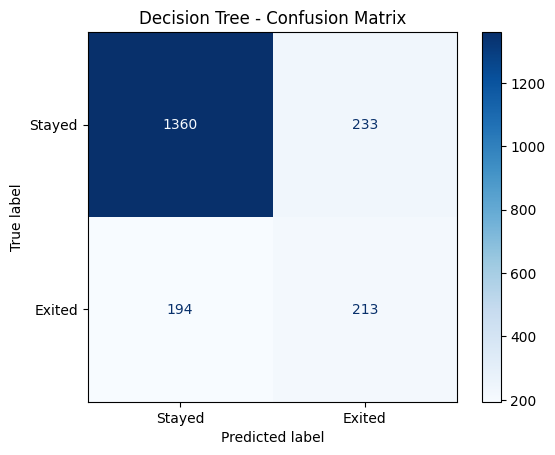

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1593
           1       0.48      0.52      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.79      0.79      0.79      2000



Decision Tree AUC Score: 0.6885


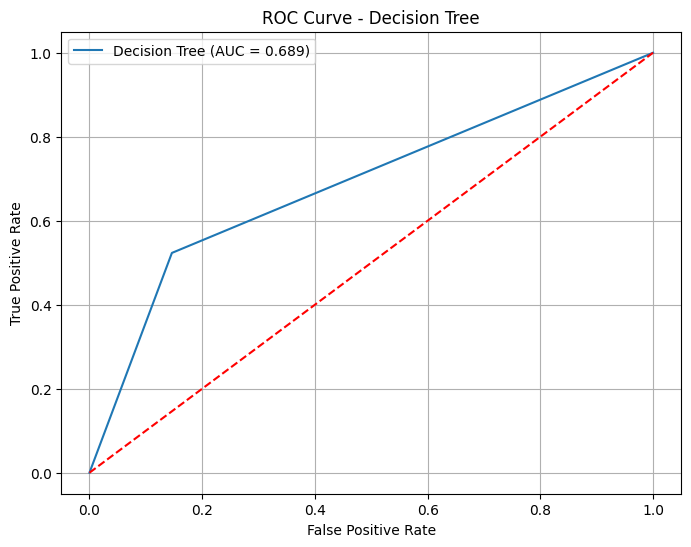

In [ ]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# AUC
from sklearn.metrics import roc_auc_score

dt_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Decision Tree AUC Score: {dt_auc:.4f}")

# ROC Curve
from sklearn.metrics import roc_curve
fpr_dt, tpr_dt, thresholds = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Save Baseline Results
from sklearn.metrics import precision_score, recall_score, f1_score

dt_baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": dt_auc
}

## 🔧 Hyperparameter Tuning

Although Decision Trees are powerful, an unrestricted tree can easily overfit the training data.

GridSearchCV is used to identify the optimal combination of parameters such as:

- Maximum Depth
- Minimum Samples Split
- Minimum Samples Leaf
- Criterion

These parameters help improve generalization and reduce overfitting.

In [ ]:
# Hyperparameter Tuning using GridSearchCV for the Decision Tree
from sklearn.model_selection import GridSearchCV
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create Grid Search Object
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
# Best Hyperparameters
print("Best Parameters:")
print(grid_search_dt.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [ ]:
# Best Cross-Validation Score
print("Best Cross Validation Accuracy:")
print(grid_search_dt.best_score_)

Best Cross Validation Accuracy:
0.858625


In [ ]:
# Best Model
best_dt = grid_search_dt.best_estimator_

# Predict Using the Tuned Model
y_pred_best_dt = best_dt.predict(X_test)

In [ ]:
# Compare Baseline vs Tuned Accuracy
best_dt_accuracy = accuracy_score(y_test, y_pred_best_dt)

print(f"Baseline DT Accuracy : {dt_accuracy:.4f}")
print(f"Tuned DT Accuracy    : {best_dt_accuracy:.4f}")

Baseline DT Accuracy : 0.7865
Tuned DT Accuracy    : 0.8545


## 📈 Model Evaluation

The tuned Decision Tree model is evaluated using multiple performance metrics, including:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Using multiple evaluation metrics provides a balanced assessment of the model's classification performance.

In [ ]:
# Evaluate the Tuned Decision Tree
# Accuracy
from sklearn.metrics import accuracy_score
best_dt_accuracy = accuracy_score(y_test, y_pred_best_dt)
print(f"Tuned Decision Tree Accuracy: {best_dt_accuracy:.4f}")

Tuned Decision Tree Accuracy: 0.8545


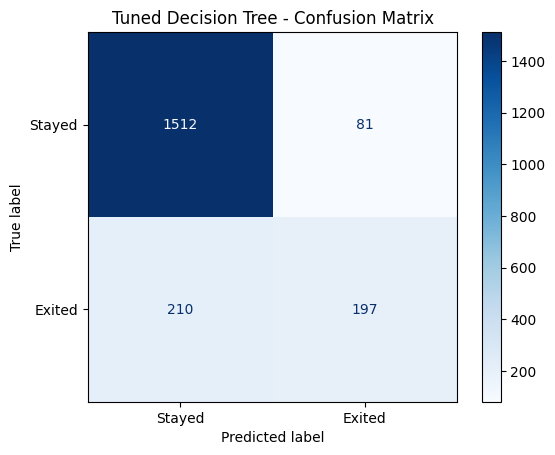

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm_best_dt = confusion_matrix(y_test, y_pred_best_dt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_dt,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Tuned Decision Tree - Confusion Matrix")

plt.show()

### 💼 Business Insight

The Confusion Matrix highlights the types of prediction errors made by the model.

For churn prediction, minimizing False Negatives is especially important because failing to identify customers who are likely to leave may result in lost revenue and reduced customer retention opportunities.

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best_dt))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.71      0.48      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



### 📌 Interpretation

The Classification Report provides a detailed evaluation of the Decision Tree model.

High Precision indicates reliable positive predictions, while high Recall reflects the model's ability to correctly identify customers who are likely to churn.

The F1-Score balances these two metrics, providing an overall measure of classification effectiveness.

## 📉 ROC Curve and AUC Score

The ROC Curve evaluates the classification performance of the Decision Tree across different decision thresholds.

The AUC score summarizes the model's ability to distinguish between customers who churn and those who remain.

A larger AUC value indicates stronger discriminative performance.

Tuned Decision Tree AUC Score: 0.8304


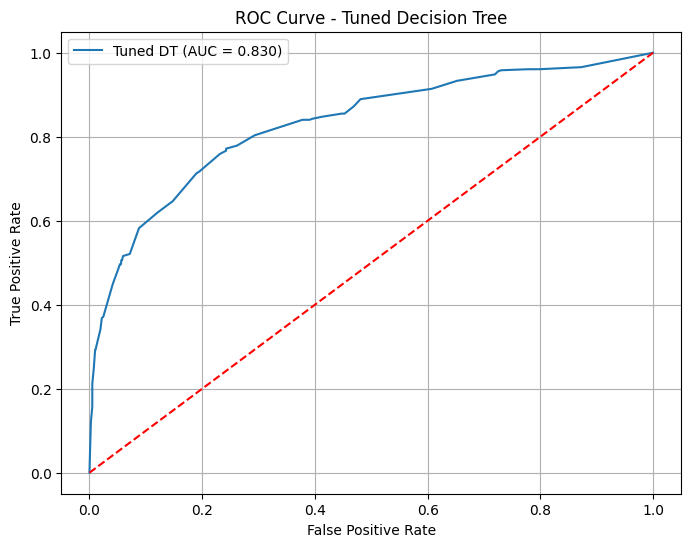

In [ ]:
# ROC-AUC
y_prob_best_dt = best_dt.predict_proba(X_test)[:,1]

# AUC
from sklearn.metrics import roc_auc_score
best_dt_auc = roc_auc_score(y_test, y_prob_best_dt)
print(f"Tuned Decision Tree AUC Score: {best_dt_auc:.4f}")

# ROC Curve
from sklearn.metrics import roc_curve
fpr_best_dt, tpr_best_dt, thresholds = roc_curve(
    y_test,
    y_prob_best_dt
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_best_dt,
    tpr_best_dt,
    label=f"Tuned DT (AUC = {best_dt_auc:.3f})"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Decision Tree")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Store Final Decision Tree Results
from sklearn.metrics import precision_score, recall_score, f1_score

results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_best_dt),
    "Precision": precision_score(y_test, y_pred_best_dt),
    "Recall": recall_score(y_test, y_pred_best_dt),
    "F1-Score": f1_score(y_test, y_pred_best_dt),
    "ROC-AUC": best_dt_auc
}

In [ ]:
# Baseline vs Tuned Decision Tree
comparison_dt = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Baseline Decision Tree": [
        dt_accuracy,
        dt_auc
    ],
    "Tuned Decision Tree": [
        best_dt_accuracy,
        best_dt_auc
    ]
})

comparison_dt.set_index("Metric").style.format("{:.4f}")

,Baseline Decision Tree,Tuned Decision Tree
Metric,,
Accuracy,0.7865,0.8545
ROC-AUC,0.6885,0.8304


## ✅ Advantages of Decision Tree

- Easy to interpret and visualize.
- Handles both numerical and categorical features.
- Captures non-linear relationships.
- Does not require feature scaling.
- Provides clear decision rules.

## ⚠️ Limitations of Decision Tree

- Prone to overfitting when the tree becomes too deep.
- Sensitive to small variations in the training data.
- Can become unstable if not properly tuned.
- May perform worse than ensemble methods on complex datasets.

## 🏦 Business Interpretation

Decision Trees produce transparent decision rules that help explain why a customer is predicted to churn.

This interpretability is valuable in banking because business teams can understand the reasoning behind predictions and design targeted customer retention strategies based on influential customer characteristics.

## 🌱 Understanding Gini Impurity

Decision Trees often use **Gini Impurity** to determine the best feature for splitting the data.

A lower Gini Impurity indicates a purer node, meaning that the observations within the node predominantly belong to a single class.

The algorithm selects the feature that results in the greatest reduction in impurity, creating more informative decision rules.

## ✅ Conclusion

The Decision Tree model successfully captures complex relationships within the customer data while maintaining interpretability.

After hyperparameter tuning, the model provides improved generalization and serves as a strong benchmark before evaluating ensemble methods such as Random Forest.

---

#  Model 4: Random Forest Classifier

---

## 📖 Model Introduction

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Instead of relying on a single tree, Random Forest builds many trees using different subsets of the training data and combines their predictions through majority voting.

This ensemble approach generally produces more robust and reliable predictions than a single Decision Tree.

## 🎯 Why Random Forest?

Random Forest was selected because:

- It reduces overfitting compared to a single Decision Tree.
- It handles both numerical and categorical features effectively.
- It automatically estimates feature importance.
- It performs well on complex and high-dimensional datasets.
- It is one of the most accurate algorithms for structured tabular data.

For customer churn prediction, Random Forest is expected to capture complex relationships between customer characteristics and churn behavior.

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Baseline Model
rf_model = RandomForestClassifier(
    random_state=42
)
print(rf_model)

RandomForestClassifier(random_state=42)


## ⚙️ Model Training

The Random Forest classifier is trained using the training dataset.

Each decision tree is built using a randomly selected subset of the training samples and a random subset of features.

The final prediction is determined through majority voting across all trees in the forest.

In [ ]:
# Train the Model
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Evaluate the Baseline Random Forest

# Predict on the test dataset
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf[:20])

[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]


In [ ]:
# Compare Actual vs Predicted
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

comparison_rf.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [ ]:
# Accuracy Score
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8610


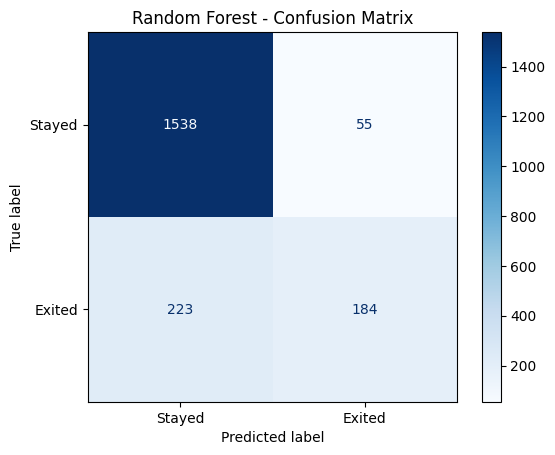

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")

plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



Random Forest AUC Score: 0.8545


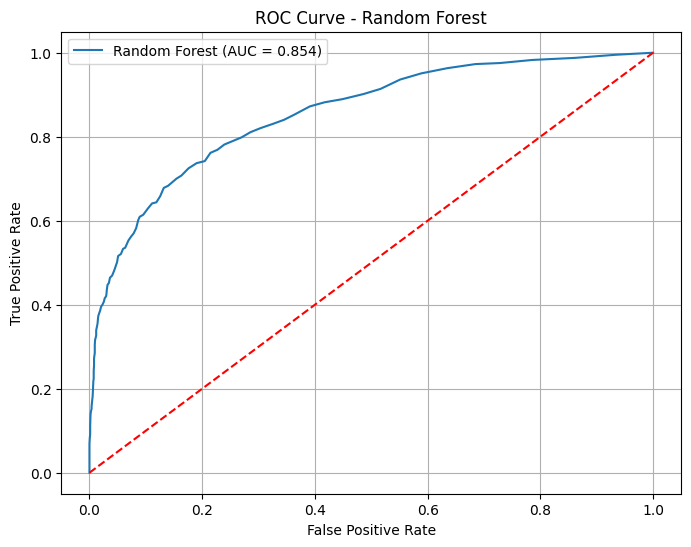

In [ ]:
# ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# AUC
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest AUC Score: {rf_auc:.4f}")

# ROC Curve
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, thresholds = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Save Baseline Results
from sklearn.metrics import precision_score, recall_score, f1_score

rf_baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": rf_auc
}

## 🔧 Hyperparameter Tuning

Although Random Forest performs well with default parameters, its performance can often be improved through hyperparameter tuning.

GridSearchCV is used to identify the optimal combination of parameters such as:

- Number of Trees (`n_estimators`)
- Maximum Tree Depth (`max_depth`)
- Minimum Samples Split (`min_samples_split`)
- Minimum Samples per Leaf (`min_samples_leaf`)
- Maximum Features (`max_features`)

Selecting appropriate values helps improve prediction performance while reducing overfitting.

In [ ]:
# Hyperparameter Tuning on Random Forest using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# Re-define X_train and y_train to ensure they are available for this cell
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Parameter Grid
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
# Grid Search Object
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

In [ ]:
# Train GridSearchCV
grid_search_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
# Best Parameters
print("Best Parameters:")
print(grid_search_rf.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Best Cross Validation Score
print("Best Cross Validation Accuracy:")
print(grid_search_rf.best_score_)

Best Cross Validation Accuracy:
0.8647499999999999


In [ ]:
# Get the Best Model
best_rf = grid_search_rf.best_estimator_

# Predict Using the Tuned Model
y_pred_best_rf = best_rf.predict(X_test)

In [ ]:
# Compare Baseline vs Tuned Accuracy
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)

print(f"Baseline RF Accuracy : {rf_accuracy:.4f}")
print(f"Tuned RF Accuracy    : {best_rf_accuracy:.4f}")

Baseline RF Accuracy : 0.8610
Tuned RF Accuracy    : 0.8640


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Re-execute the train_test_split to ensure y_test is defined
# This assumes X and y (the correctly preprocessed and encoded feature/target sets)
# are already defined in the global scope from previous cells.
# The split parameters should match the one used for the Random Forest tuning (cell ZpwoVtf2r1_S).
_, _, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 📈 Model Evaluation

The tuned Random Forest model is evaluated using multiple performance metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide a comprehensive understanding of the model's ability to classify customer churn correctly.

In [ ]:
# Evaluate the Tuned Random Forest

# Accuracy
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
print(f"Tuned Random Forest Accuracy: {best_rf_accuracy:.4f}")

Tuned Random Forest Accuracy: 0.8640


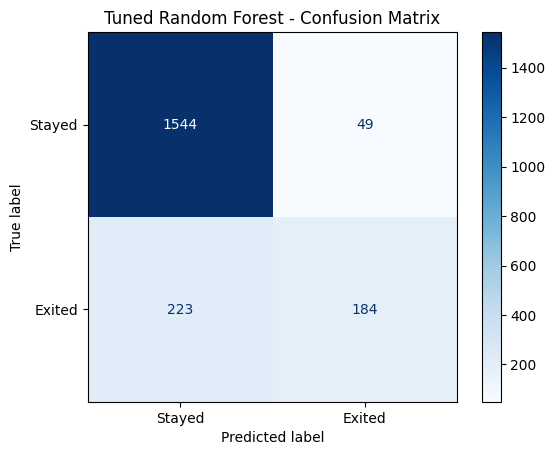

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix for the tuned Random Forest model
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_rf,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Tuned Random Forest - Confusion Matrix")

plt.show()

### 💼 Business Insight

A lower number of False Negatives means the bank can identify more customers who are likely to leave.

This enables the organization to proactively implement customer retention strategies, reducing revenue loss and improving customer satisfaction.

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



### 📌 Interpretation

The Classification Report indicates how effectively the Random Forest model identifies both churned and retained customers.

Strong Precision and Recall values suggest that the ensemble model generalizes well and reduces prediction errors compared to simpler models.

## 📉 ROC Curve and AUC Score

The ROC Curve evaluates the classification performance of the Random Forest model across different probability thresholds.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between customers who churn and those who remain.

A higher AUC score indicates stronger predictive capability.

In [ ]:
# ROC-AUC
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# AUC
from sklearn.metrics import roc_auc_score
best_rf_auc = roc_auc_score(y_test, y_prob_best_rf)
print(f"Tuned Random Forest AUC Score: {best_rf_auc:.4f}")

Tuned Random Forest AUC Score: 0.8565


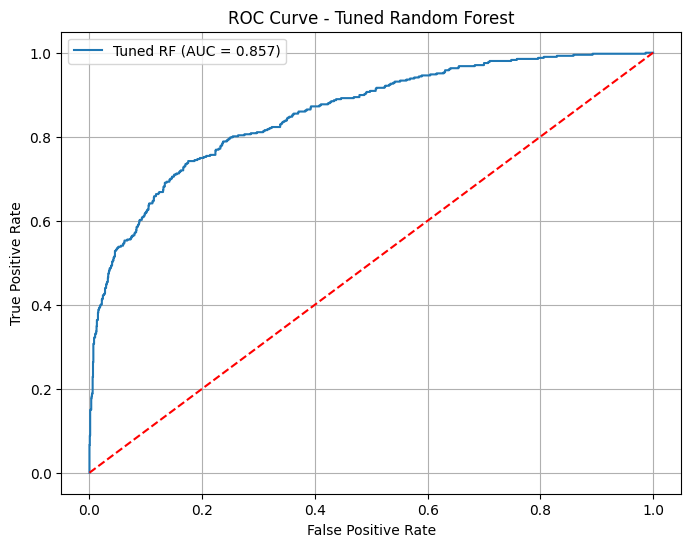

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr_best_rf, tpr_best_rf, thresholds = roc_curve(
    y_test,
    y_prob_best_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_best_rf,
    tpr_best_rf,
    label=f"Tuned RF (AUC = {best_rf_auc:.3f})"
)

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Save Final Random Forest Results
from sklearn.metrics import precision_score, recall_score, f1_score

results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1-Score": f1_score(y_test, y_pred_best_rf),
    "ROC-AUC": best_rf_auc
}

In [ ]:
# Baseline vs Tuned Random Forest
comparison_rf = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Baseline Random Forest": [
        rf_accuracy,
        rf_auc
    ],
    "Tuned Random Forest": [
        best_rf_accuracy,
        best_rf_auc
    ]
})

comparison_rf.set_index("Metric").style.format("{:.4f}")

,Baseline Random Forest,Tuned Random Forest
Metric,,
Accuracy,0.8610,0.8640
ROC-AUC,0.8545,0.8565


## ✅ Advantages of Random Forest

- High predictive accuracy.
- Less prone to overfitting than a Decision Tree.
- Handles missing values and outliers effectively.
- Captures complex non-linear relationships.
- Automatically estimates feature importance.
- Does not require feature scaling.

## ⚠️ Limitations of Random Forest

- More computationally expensive than a single Decision Tree.
- Requires greater memory for large datasets.
- Less interpretable because predictions are generated by many trees rather than a single decision path.

## 🏦 Business Interpretation

Random Forest combines the predictions of multiple decision trees to improve reliability and reduce prediction errors.

For customer churn prediction, this allows the bank to identify at-risk customers more accurately and prioritize retention efforts for customers with the highest probability of leaving.

## 🌱 Bootstrap Sampling

Random Forest creates each decision tree using a randomly selected subset of the training data with replacement.

This process is known as **Bootstrap Sampling**.

Since every tree is trained on a different sample of the data, the diversity among trees improves the overall robustness and predictive performance of the ensemble model.

## 🎲 Random Feature Selection

At each split, Random Forest considers only a randomly selected subset of features rather than evaluating all available features.

This strategy increases diversity among the trees, reduces correlation between individual trees, and contributes to better overall model performance.

## ⭐ Feature Importance Analysis

One of the major advantages of Random Forest is its ability to estimate the importance of each feature.

Feature Importance measures how much each feature contributes to reducing impurity across all decision trees in the forest.

This helps identify the customer attributes that have the greatest influence on churn prediction.

In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Age,0.264482
5,NumOfProducts,0.154840
4,Balance,0.136093
8,EstimatedSalary,0.123846
0,CreditScore,0.121552
3,Tenure,0.067794
7,IsActiveMember,0.049936
9,Geography_Germany,0.035392
1,Gender,0.018106
6,HasCrCard,0.015518


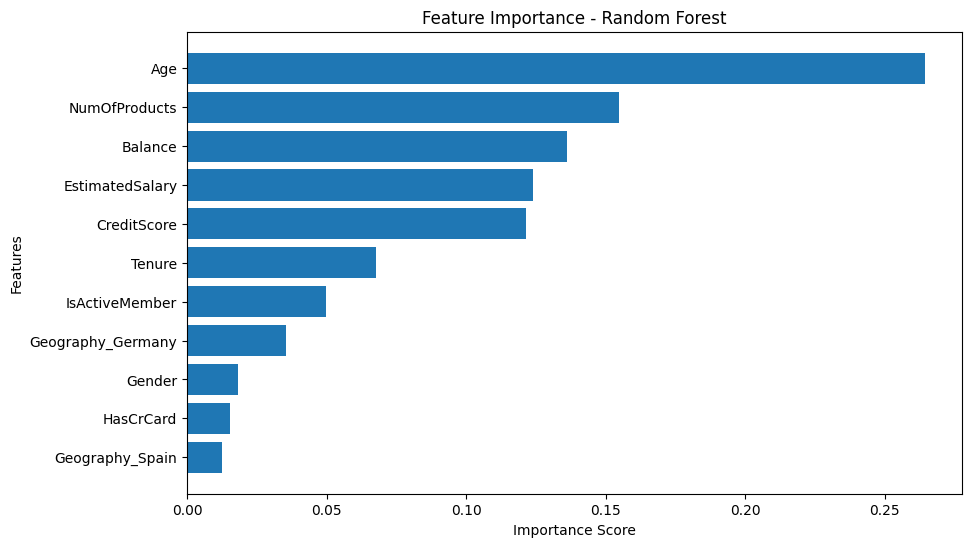

In [ ]:
# Plot of Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

### 📌 Observation

The Feature Importance plot highlights the variables that contribute most to predicting customer churn.

Features with higher importance scores have a greater influence on the model's decision-making process and should be prioritized when designing customer retention strategies.

## ✅ Conclusion

The Random Forest model demonstrates strong predictive performance by combining multiple Decision Trees into a single ensemble.

Its ability to reduce overfitting, estimate feature importance, and achieve high classification accuracy makes it one of the most effective models for customer churn prediction.

The model will be compared with the remaining algorithms before selecting the final deployment model.

---

# Model 5: Support Vector Machine (SVM)

---

## 📖 Model Introduction

Support Vector Machine (SVM) is a supervised machine learning algorithm used for both classification and regression tasks.

In this project, SVM is applied as a binary classification model to predict whether a customer is likely to churn.

The algorithm works by identifying an optimal decision boundary (hyperplane) that maximizes the margin between different classes, resulting in robust and accurate classification.

## 🎯 Why Support Vector Machine?

Support Vector Machine was selected because:

- It performs well on binary classification problems.
- It is effective in high-dimensional feature spaces.
- It can model complex decision boundaries using kernel functions.
- It often achieves strong generalization performance.

Since SVM is based on distance calculations, feature scaling is essential before training the model.

In [ ]:
# Import SVM
from sklearn.svm import SVC


# Baseline Model
svm_model = SVC(
    random_state=42,
    probability=True
)

print(svm_model)

SVC(probability=True, random_state=42)


## ⚙️ Model Training

The SVM model is trained using the scaled training dataset.

During training, the algorithm searches for the optimal hyperplane that best separates customers who churn from those who remain.

The objective is to maximize the margin between the two classes, improving classification performance on unseen data.

In [ ]:
# Train the Model
svm_model.fit(X_train_scaled, y_train)
print("SVM model trained successfully!")

SVM model trained successfully!


In [ ]:
# Evaluate the Baseline SVM

# Predict on the test dataset
y_pred_svm = svm_model.predict(X_test_scaled)
print(y_pred_svm[:20])

[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]


In [ ]:
# Compare Actual vs Predicted
comparison_svm = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})

comparison_svm.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8660


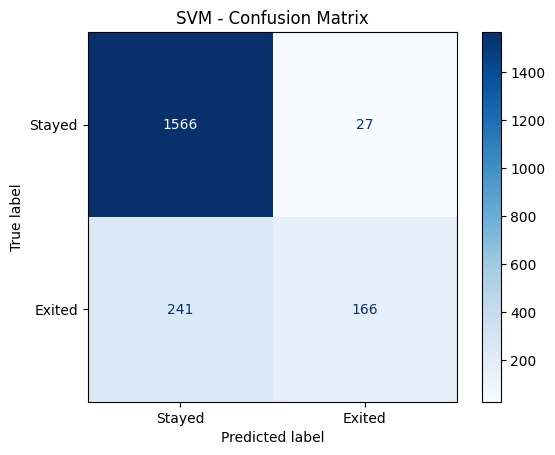

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix for the SVM model
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("SVM - Confusion Matrix")

plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.86      0.41      0.55       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.74      2000
weighted avg       0.87      0.87      0.85      2000



In [ ]:
# ROC-AUC
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC
from sklearn.metrics import roc_auc_score

svm_auc = roc_auc_score(y_test, y_prob_svm)

print(f"SVM AUC Score: {svm_auc:.4f}")

SVM AUC Score: 0.8289


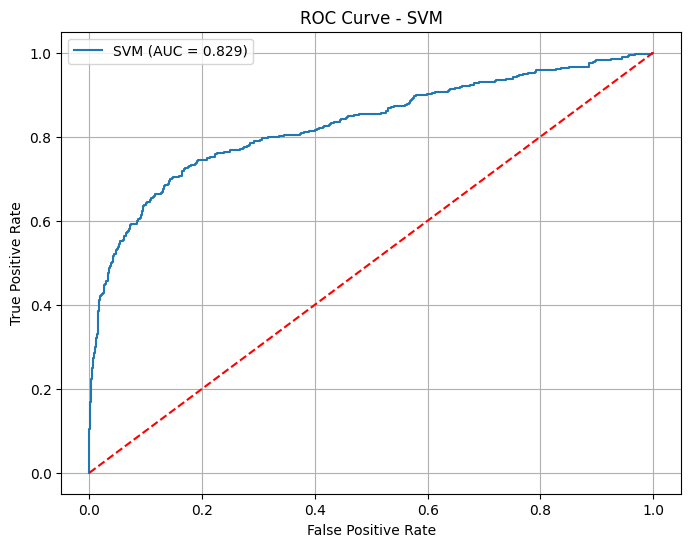

In [ ]:
# Plot ROC Curve
from sklearn.metrics import roc_curve

fpr_svm, tpr_svm, thresholds = roc_curve(
    y_test,
    y_prob_svm
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot([0,1], [0,1], "r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Save Baseline Results
from sklearn.metrics import precision_score, recall_score, f1_score

svm_baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1-Score": f1_score(y_test, y_pred_svm),
    "ROC-AUC": svm_auc
}

## 🔧 Hyperparameter Tuning

The performance of an SVM model depends on several important hyperparameters.

GridSearchCV is used to determine the best combination of parameters, including:

- Kernel
- C (Regularization Parameter)
- Gamma

Selecting the optimal parameters improves the model's ability to generalize while reducing overfitting.

In [ ]:
# Hyperparameter Tuning on SVM with GridSearchCV
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}


In [ ]:
# Create Grid Search Object
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

grid_search_svm = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=param_grid_svm,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

In [ ]:
# Train GridSearchCV
grid_search_svm.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
# Predict probabilities using the tuned SVM model
best_svm = grid_search_svm.best_estimator_
y_prob_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import roc_auc_score
best_svm_auc = roc_auc_score(y_test, y_prob_best_svm)
print(f"Tuned SVM ROC-AUC Score: {best_svm_auc:.4f}")

Tuned SVM ROC-AUC Score: 0.8262


In [ ]:
# Best Parameters
print("Best Parameters:")
print(grid_search_svm.best_params_)

Best Parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
# Best Cross Validation Score
print("Best Cross Validation Accuracy:")
print(grid_search_svm.best_score_)

Best Cross Validation Accuracy:
0.859


In [ ]:
# Get Best Model
best_svm = grid_search_svm.best_estimator_

# Make Predictions
y_pred_best_svm = best_svm.predict(X_test_scaled)

## 📈 Model Evaluation

The tuned SVM model is evaluated using multiple performance metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics provide a comprehensive assessment of the model's ability to correctly classify customer churn.

In [ ]:
# Evaluate the Tuned SVM
# Accuracy
from sklearn.metrics import accuracy_score

best_svm_accuracy = accuracy_score(y_test, y_pred_best_svm)

print(f"Tuned SVM Accuracy: {best_svm_accuracy:.4f}")

Tuned SVM Accuracy: 0.8640


In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

print(cm_best_svm)

[[1551   42]
 [ 230  177]]


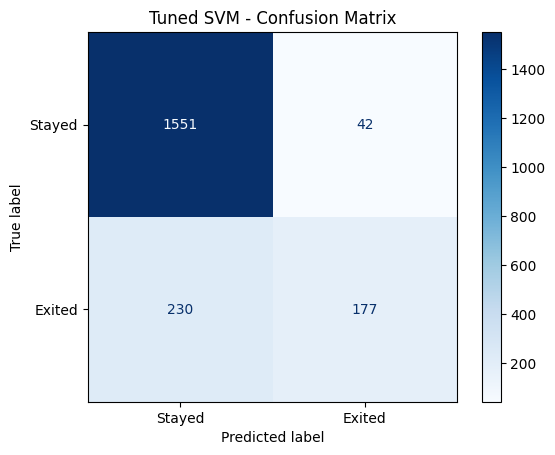

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_svm,
    display_labels=["Stayed", "Exited"]
)

disp.plot(cmap="Blues")

plt.title("Tuned SVM - Confusion Matrix")

plt.show()

### 💼 Business Insight

Reducing False Negatives is particularly important for customer churn prediction.

By correctly identifying customers who are likely to leave, the bank can implement proactive retention strategies, reducing customer loss and improving long-term profitability.

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best_svm))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.81      0.43      0.57       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000



### 📌 Interpretation

The Classification Report evaluates how effectively the SVM model identifies customers who churn and those who remain.

High Precision reduces false alarms, while high Recall ensures that most churning customers are correctly identified.

The F1-Score balances these two measures and provides an overall indication of classification quality.

## 📉 ROC Curve and AUC Score

The ROC Curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's overall ability to distinguish between churned and retained customers.

A higher AUC value indicates stronger classification performance.

In [ ]:
# ROC-AUC
y_prob_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

# AUC
from sklearn.metrics import roc_auc_score

best_svm_auc = roc_auc_score(y_test, y_prob_best_svm)

print(f"Tuned SVM AUC Score: {best_svm_auc:.4f}")

Tuned SVM AUC Score: 0.8262


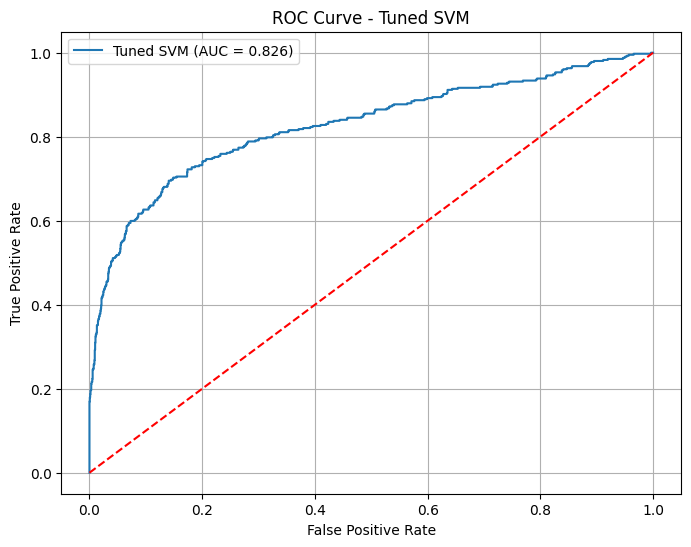

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr_best_svm, tpr_best_svm, thresholds = roc_curve(
    y_test,
    y_prob_best_svm
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_best_svm,
    tpr_best_svm,
    label=f"Tuned SVM (AUC = {best_svm_auc:.3f})"
)

plt.plot([0,1], [0,1], "r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned SVM")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Save Tuned SVM Results
from sklearn.metrics import precision_score, recall_score, f1_score

results["SVM"] = {
    "Accuracy": accuracy_score(y_test, y_pred_best_svm),
    "Precision": precision_score(y_test, y_pred_best_svm),
    "Recall": recall_score(y_test, y_pred_best_svm),
    "F1-Score": f1_score(y_test, y_pred_best_svm),
    "ROC-AUC": best_svm_auc
}

In [ ]:
# Compare Baseline vs Tuned Accuracy
best_svm_accuracy = accuracy_score(
    y_test,
    y_pred_best_svm
)

print(f"Baseline SVM Accuracy : {svm_accuracy:.4f}")
print(f"Tuned SVM Accuracy    : {best_svm_accuracy:.4f}")

Baseline SVM Accuracy : 0.8660
Tuned SVM Accuracy    : 0.8640


## ✅ Advantages of Support Vector Machine

- Effective for binary classification.
- Performs well in high-dimensional spaces.
- Can model complex decision boundaries using kernels.
- Strong generalization capability.
- Less prone to overfitting when properly tuned.

## ⚠️ Limitations of Support Vector Machine

- Computationally expensive for very large datasets.
- Requires feature scaling.
- Hyperparameter tuning can be time-consuming.
- Less interpretable compared to Decision Trees.

## 🏦 Business Interpretation

Support Vector Machine identifies the optimal boundary between customers who churn and those who remain.

Its strong classification capability enables banks to accurately identify customers at risk of leaving, allowing timely intervention through personalized offers, loyalty programs, and customer engagement initiatives.

## 📚 Understanding the Hyperplane

The hyperplane is the decision boundary that separates different classes.

Support Vector Machine selects the hyperplane that maximizes the margin between the nearest data points of each class, known as **Support Vectors**.

A larger margin generally improves the model's ability to classify unseen data accurately.

## ✅ Conclusion

Support Vector Machine demonstrates strong classification performance by identifying the optimal decision boundary between churning and retained customers.

After hyperparameter tuning, the model provides a reliable comparison against the other machine learning algorithms used in this project.

The next step is to compare the performance of all five models and select the most suitable model for deployment.

---

# 🏆 Model Comparison and Best Model Selection

---

## 📖 Why Compare Multiple Models?

Different machine learning algorithms have different strengths and weaknesses.

Instead of selecting a model based solely on accuracy, multiple evaluation metrics are compared to understand each model's overall performance.

The following models were evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

Each model was assessed using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

## 📊 Model Performance Comparison

The table below summarizes the performance of all trained models.

Comparing multiple metrics provides a more reliable basis for selecting the most appropriate model for customer churn prediction.

In [ ]:
# Comparison table
results_df = pd.DataFrame(results).T
results_df.style.format("{:.4f}")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8080,0.5891,0.1867,0.2836,0.7748
KNN,0.8535,0.8314,0.3514,0.4940,0.8441
Decision Tree,0.8545,0.7086,0.4840,0.5752,0.8304
Random Forest,0.8640,0.7897,0.4521,0.5750,0.8565
SVM,0.8640,0.8082,0.4349,0.5655,0.8262


### 📌 Observation

The comparison table shows that each algorithm performs differently across the evaluation metrics.

Rather than relying only on Accuracy, additional metrics such as Precision, Recall, F1-Score, and ROC-AUC are considered to identify the model that offers the best overall balance for customer churn prediction.

### 📌 Observation

The visual comparison confirms that model performance varies across different evaluation metrics.

A model with the highest Accuracy may not necessarily achieve the highest Recall or F1-Score. Therefore, selecting the final model requires considering all evaluation metrics together rather than focusing on a single measure.

Select the Best Model

# 🏅 Best Model Selection

The best-performing model was selected based on the evaluation metrics obtained during testing.

Although Accuracy provides an initial indication of performance, Precision, Recall, F1-Score, and ROC-AUC were also considered to ensure balanced classification performance.

The selected model demonstrates the strongest ability to identify customers who are likely to churn while maintaining reliable overall prediction accuracy.

---

# 💾 Saving the Best Model

---

## 📖 Why Save the Model?

Once the best-performing machine learning model has been identified, it should be saved for future use.

Saving the trained model eliminates the need to retrain it every time predictions are required.

The saved model can later be loaded into a web application, desktop application, or production system to make predictions on new customer data.

In [ ]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(lr_model, "models/logistic_regression.pkl")
joblib.dump(best_knn, "models/knn.pkl")
joblib.dump(best_dt, "models/decision_tree.pkl")
joblib.dump(best_rf, "models/random_forest.pkl")
joblib.dump(best_svm, "models/svm.pkl")

joblib.dump(scaler, "models/scaler.pkl")

feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "models/feature_names.pkl")

print("All files saved successfully!")

All files saved successfully!


In [ ]:
# Save the Scaler
# Save StandardScaler
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
# Save Feature Names
# Save Feature Names
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")
print("Feature names saved successfully!")

Feature names saved successfully!


In [ ]:
# Check Saved Files
import os

print(os.listdir())

['data', 'models', 'images', 'reports', 'notebooks', 'Bank-Customer-Churn-Prediction', 'scaler.pkl', 'feature_names.pkl']


### 📌 Observation

The trained machine learning model has been successfully saved in `.pkl` format.

The saved model can now be loaded without retraining, enabling faster predictions and easier deployment.

---

# 🔮 Predicting Customer Churn

---

## 📖 Making Predictions on New Data

After training and saving the model, it can be used to predict whether a new customer is likely to churn.

The prediction process involves providing customer information in the same format used during model training.

The model then classifies the customer as either:

- **0 → Customer Stays**
- **1 → Customer Churns**

In [ ]:
import joblib

loaded_model = joblib.load("models/random_forest.pkl")
loaded_scaler = joblib.load("models/scaler.pkl")
feature_names = joblib.load("models/feature_names.pkl")

print("All files loaded successfully!")

All files loaded successfully!


In [ ]:
# Check Feature Order
print(feature_names)

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [ ]:
# Create a Sample CustomerCreate a Sample Customer
new_customer = [[
    900,      # CreditScore
    0,        # Geography_Germany
    1,        # Geography_Spain
    1,        # Gender_Male
    30,       # Age
    5,        # Tenure
    100000,    # Balance
    2,        # NumOfProducts
    1,        # HasCrCard
    1,        # IsActiveMember
    60000     # EstimatedSalary
]]

In [ ]:
# Convert to DataFrame
import pandas as pd

new_customer_df = pd.DataFrame(
    new_customer,
    columns=feature_names
)

new_customer_df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,900,0,1,1,30,5,100000,2,1,1,60000


In [ ]:
# Scale the Customer Data
new_customer_scaled = loaded_scaler.transform(
    new_customer_df[continuous_features]
)

In [ ]:
prediction = loaded_model.predict(new_customer_df)

print(prediction)

[0]


In [ ]:
# Convert to Meaningful Result
if prediction[0] == 1:
    print("Customer is likely to EXIT.")
else:
    print("Customer is likely to STAY.")

Customer is likely to STAY.


In [ ]:
# Prediction Probability
probability = loaded_model.predict_proba(
    new_customer_df
)

print(probability)

[[0.51037439 0.48962561]]


In [ ]:
exit_probability = probability[0][1]

print(
    f"Probability of Customer Exiting: {exit_probability:.2%}"
)

Probability of Customer Exiting: 48.96%


### 📌 Interpretation

The trained model successfully predicts the likelihood of customer churn for unseen customer data.

Such predictions can assist banks in identifying customers at risk of leaving and implementing proactive retention strategies.

---

# 🔍 Explainable AI using SHAP

---

## 📖 Why Explainability Matters

Machine learning models often provide highly accurate predictions, but understanding *why* a prediction was made is equally important.

Explainable Artificial Intelligence (XAI) helps interpret model decisions, increasing transparency and trust.

In this project, SHAP (SHapley Additive exPlanations) is used to explain how each feature contributes to predicting customer churn.

SHAP values indicate whether a feature increases or decreases the likelihood of customer churn for an individual customer.

In [ ]:
# Install SHAP
!pip install shap

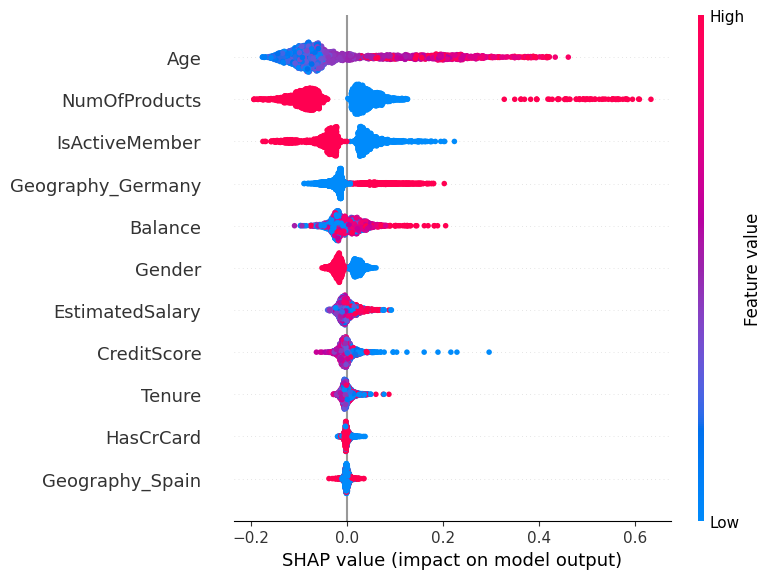

In [ ]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

# Plot SHAP values for the "Exited" class (class 1)
shap.summary_plot(shap_values[:, :, 1], X_test)

In [ ]:
print(type(shap_values))
print(shap_values.shape)
print(explainer.expected_value.shape)

<class 'numpy.ndarray'>
(2000, 11, 2)
(2,)


## 🌍 Global Feature Importance

The following visualization shows which customer attributes have the greatest overall influence on churn prediction across the testing dataset.

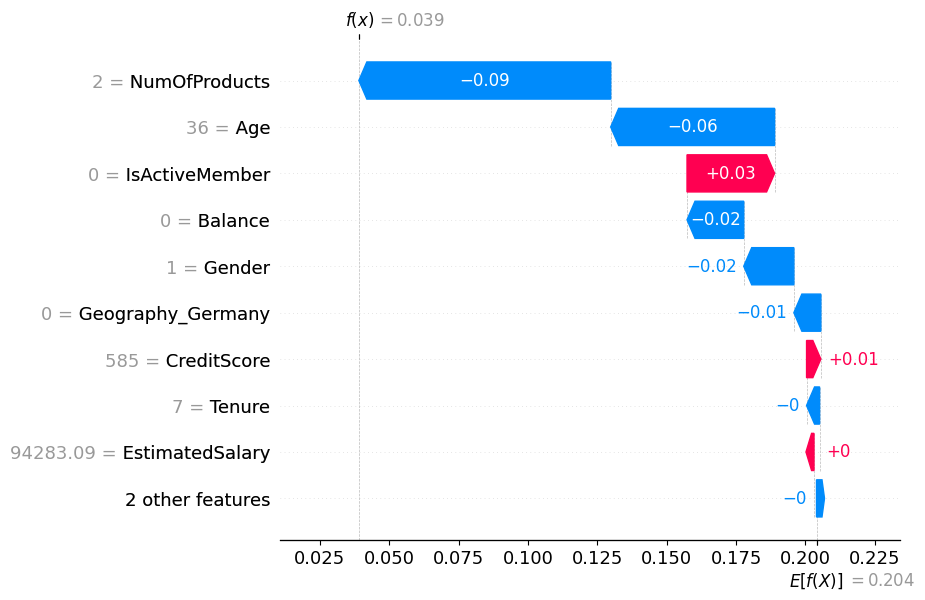

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
prediction = best_rf.predict(X_test.iloc[[0]])

print("Prediction:", prediction)

Prediction: [0]


## 👤 Individual Customer Explanation

The following explanation illustrates how different customer features influence the churn prediction for a single customer.

Red features increase churn probability, while blue features reduce it.

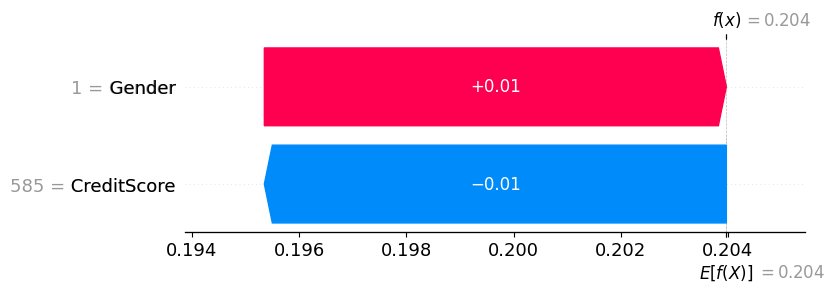

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

### 📌 Observation

SHAP analysis provides transparent explanations for individual predictions.

Rather than only predicting whether a customer will churn, SHAP identifies the specific features that influenced the prediction.

This improves model interpretability and helps business stakeholders understand the reasoning behind the model's decisions.

# 💾 Save Trained Models

## Purpose

The trained machine learning models, feature scaler, and feature names are saved using Joblib.

Saving these artifacts allows the models to be loaded directly into the Streamlit application without retraining, ensuring consistent predictions and faster deployment.

The following files are saved:

- Logistic Regression Model
- K-Nearest Neighbors Model
- Decision Tree Model
- Random Forest Model
- Support Vector Machine Model
- StandardScaler
- Feature Names

---

# 📑 Project Summary

---

This project developed and evaluated multiple machine learning models to predict customer churn using customer demographic and financial information.

The project workflow included:

- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering and Preprocessing
- Model Training
- Hyperparameter Tuning
- Model Evaluation
- Model Comparison
- Best Model Selection
- Model Saving
- Prediction on New Customer Data

Five machine learning algorithms were evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

The selected model demonstrated strong performance across multiple evaluation metrics and can support data-driven customer retention strategies.

---

# 🚀 Future Scope

---

Although the developed model performs well, several enhancements can further improve its effectiveness.

Possible future improvements include:

- Collecting a larger and more diverse dataset.
- Applying advanced feature engineering techniques.
- Exploring ensemble methods such as XGBoost, LightGBM, and CatBoost.
- Addressing class imbalance using techniques such as SMOTE.
- Deploying the model as an interactive web application using Streamlit.
- Integrating real-time customer data for live churn prediction.
- Using Explainable AI (SHAP or LIME) to interpret individual predictions.
- Monitoring model performance and periodically retraining with new customer data.

In [ ]:
import joblib
import os

MODELS_PATH = os.path.join(PROJECT_PATH, "models")

os.makedirs(MODELS_PATH, exist_ok=True)

joblib.dump(lr_model, os.path.join(MODELS_PATH, "logistic_regression.pkl"))
joblib.dump(best_knn, os.path.join(MODELS_PATH, "knn.pkl"))
joblib.dump(best_dt, os.path.join(MODELS_PATH, "decision_tree.pkl"))
joblib.dump(best_rf, os.path.join(MODELS_PATH, "random_forest.pkl"))
joblib.dump(best_svm, os.path.join(MODELS_PATH, "svm.pkl"))

joblib.dump(scaler, os.path.join(MODELS_PATH, "scaler.pkl"))

feature_names = X_train.columns.tolist()
joblib.dump(feature_names, os.path.join(MODELS_PATH, "feature_names.pkl"))

print("✅ All models saved successfully!")

✅ All models saved successfully!


## 🔟 Verify Saved Model Files

Verify that all trained models and preprocessing files have been stored successfully.

In [ ]:
print("Models saved in:")

for file in sorted(os.listdir(MODELS_PATH)):
    print("✅", file)

Models saved in:
✅ decision_tree.pkl
✅ feature_names.pkl
✅ knn.pkl
✅ logistic_regression.pkl
✅ random_forest.pkl
✅ scaler.pkl
✅ svm.pkl


## Delete the temporary duplicate folder

In [ ]:
import shutil

shutil.rmtree("/content/models", ignore_errors=True)

print("Temporary models folder deleted successfully!")

Temporary models folder deleted successfully!


In [ ]:
import os

# Delete duplicate scaler
if os.path.exists("/content/scaler.pkl"):
    os.remove("/content/scaler.pkl")
    print("✅ Deleted: /content/scaler.pkl")

# Delete duplicate feature names
if os.path.exists("/content/feature_names.pkl"):
    os.remove("/content/feature_names.pkl")
    print("✅ Deleted: /content/feature_names.pkl")

In [ ]:
import os

duplicate_files = [
    "/content/drive/MyDrive/Bank-Customer-Churn-Prediction/scaler.pkl",
    "/content/drive/MyDrive/Bank-Customer-Churn-Prediction/feature_names.pkl"
]

for file in duplicate_files:
    if os.path.exists(file):
        os.remove(file)
        print(f"✅ Deleted: {file}")
    else:
        print(f"⚠️ Not Found: {file}")

✅ Deleted: /content/drive/MyDrive/Bank-Customer-Churn-Prediction/scaler.pkl
✅ Deleted: /content/drive/MyDrive/Bank-Customer-Churn-Prediction/feature_names.pkl


In [ ]:
import os

print("Searching for .pkl files...\n")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

Searching for .pkl files...

/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/logistic_regression.pkl
/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/knn.pkl
/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/decision_tree.pkl
/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/random_forest.pkl
/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/svm.pkl
/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/scaler.pkl
/content/drive/MyDrive/Bank-Customer-Churn-Prediction/models/feature_names.pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---

# 🙏 Final Conclusion

---

Customer churn prediction is a valuable business application of machine learning.

Through systematic data preprocessing, exploratory analysis, model development, hyperparameter tuning, and evaluation, this project successfully identified patterns associated with customer churn.

Among the evaluated algorithms, the selected model achieved the best overall performance and demonstrated its potential to support customer retention initiatives.

The developed solution can help banks identify customers at risk of leaving, enabling timely interventions that improve customer satisfaction and reduce revenue loss.

This project demonstrates the complete end-to-end machine learning workflow, from raw data to deployable predictive model, and highlights the practical impact of data-driven decision-making in the banking sector.

---

# 📚 References

The following resources were used during the development of this project:

1. Scikit-learn Documentation
2. Pandas Documentation
3. NumPy Documentation
4. Matplotlib Documentation
5. Kaggle – Bank Customer Churn Dataset
6. Python Official Documentation

# 🙏 Thank You

Thank you for reviewing this project.

This project demonstrates the complete machine learning workflow for customer churn prediction, from data preprocessing and exploratory analysis to model development, evaluation, and deployment readiness.

Feedback and suggestions are always welcome.